# make tree files for iTOL

In [1]:
# import dendropy
# # input_file = "/Users/longolab/Desktop/database/GTDB/bac120.tree"
# # output_file = "./data/output/bac120_to_itol_noboot.tree"
# # input_file = "/Users/tseamuscorlett/Desktop/ar53_r207.tree"
# # output_file = "/Users/tseamuscorlett/Desktop/ar53_r207_to_itol_noboot.tree"


# def is_float(s):
#     """Check if a string can be converted to a float.
#     Parameters
#     ----------
#     s : str
#         String to evaluate.
#     Returns
#     -------
#     boolean
#         True if string can be converted, else False.
#     """
#     try:
#         float(s)
#     except ValueError:
#         return False

#     return True



# def parse_label(label):
#     """Parse a Newick label which may contain a support value, taxon, and/or auxiliary information.
#     Parameters
#     ----------
#     label : str
#         Internal label in a Newick tree.
#     Returns
#     -------
#     float
#         Support value specified by label, or None
#     str
#         Taxon specified by label, or None
#     str
#         Auxiliary information, on None
#     """

#     support = None
#     taxon = None
#     auxiliary_info = None

#     if label:
#         label = label.strip()
#         if '|' in label:
#             label, auxiliary_info = label.split('|')

#         if ':' in label:
#             support, taxon = label.split(':')
#             support = float(support)
#         else:
#             if is_float(label):
#                 support = float(label)
#             elif label != '':
#                 taxon = label

#     return support, taxon, auxiliary_info


# intree= dendropy.Tree.get_from_path(input_file,
#                                     schema='newick',
#                                     rooting='force-rooted',
#                                     preserve_underscores=True)

# for node in intree.internal_nodes():
#     if node.label:
#         bootstrap,label,_aux = parse_label(node.label)
#         if label:
#             label = label.replace('; ',';').replace(';','|').replace("'","").lstrip('')
#         node.label = label
#         if node.edge.length:
#                 #node.edge.length = f'{node.edge.length}[{bootstrap}]'
#                 node.edge.length = f'{node.edge.length}'

# intree.write_to_path(output_file, schema='newick', suppress_rooting=True,unquoted_underscores=True)


# prepare annotation files for iTOL

In [2]:
import requests
import csv
import ast
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu
from decimal import Decimal

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()
    
def rxnWith(xgroup, rn2rules):
    rxnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rxnWithX.append(reaction)
                break
    return rxnWithX

In [3]:
arc = csv2dict('iTOLprep/xgroup2genomes_archaea.csv')
euk = csv2dict('iTOLprep/xgroup2genomes_eukaryotes.csv')
x2modules = csv2dict('../data/assets/xgroup2/xgroup2modules.csv')
x2names = csv2dict('../data/assets/xgroup2/xgroup2names.csv')
x2ns = csv2dict('../data/assets/xgroup2/xgroup2networkSize.csv')
modules = csv2dict('../data/assets/module2name.csv')

xgroup2ds_a = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_archaea_recovered.csv')
xgroup2ds_b = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_bacteria_recovered.csv')
xgroup2ds_e = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_eukaryotes_recovered.csv')

x2rxn = {}
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
for xgroup in x2ns.keys():
    x2rxn[xgroup] = rxnWith(xgroup, rn2rules)


print(len(arc))
print(len(euk))
print(len(x2modules))
print(len(x2names))
print(len(modules))

print(len(xgroup2ds_a))
print(len(xgroup2ds_b))
print(len(xgroup2ds_e))

45
45
274
237
479
2230
2230
2230


In [4]:
for key, values in arc.items():
    print(key, len(values))

3997 21
1055 0
136 652
158 0
185 0
199 0
2010 225
239 3357
270 637
3001 371
3052 1808
309 3338
3115 1087
319 2344
3688 974
374 7
3754 1702
3896 17
4004 2504
4019 806
4022 741
4028 319
4048 334
4076 224
4110 29
4126 859
4160 1274
4237 10
4295 261
5084 57
528 849
582 0
590 169
6051 0
6096 1
640 0
7513 1534
7551 456
7553 1375
7567 1078
842 1418
869 1249
875 1900
876 452
9 334


In [5]:
for key, values in euk.items():
    print(key, len(values))

3997 49
1055 0
136 172
158 78
185 17
199 81
2010 126
239 196
270 86
3001 9
3052 139
309 196
3115 187
319 196
3688 13
374 3
3754 167
3896 123
4004 188
4019 172
4022 93
4028 122
4048 105
4076 176
4110 92
4126 149
4160 2
4237 0
4295 16
5084 182
528 142
582 0
590 126
6051 0
6096 3
640 0
7513 40
7551 9
7553 18
7567 123
842 8
869 0
875 120
876 69
9 194


In [6]:
bacNum = csv2dict('iTOLprep/xgroup2genomesNum_bacteria.csv')

for x, num in bacNum.items():
    print(x, int(num))

3997 1191
1055 10
136 21063
158 715
185 524
199 186
2010 36314
239 60749
270 56880
3001 20177
3052 34881
309 62089
3115 13530
319 48026
3688 19274
374 2664
3754 59283
3896 55758
4004 57179
4019 56273
4022 23312
4028 19532
4048 18017
4076 57240
4110 12635
4126 35246
4160 17518
4237 2597
4295 5153
5084 37943
528 22293
582 365
590 14398
6051 462
6096 6830
640 138
7513 21242
7551 10459
7553 23238
7567 31479
842 20376
869 1695
875 50429
876 55227
9 45356


In [7]:
len(bacNum)

45

In [8]:
bac = csv2dict('iTOLprep/xgroup2genomes_bacteria.csv')
# most have too many genomes! => cut down to 1 + 10 = 11 xgroups

for key, values in bac.items():
    print(key, len(values))

3997 1191
1055 10
158 715
185 524
199 186
374 2664
4237 2597
582 365
6051 462
640 138
869 1695


In [9]:
arc['3997']

['GB_GCA_012961645.1',
 'RS_GCF_000970085.1',
 'GB_GCA_002504495.1',
 'GB_GCA_000350305.1',
 'GB_GCA_013330315.1',
 'GB_GCA_013374385.1',
 'GB_GCA_014361205.1',
 'GB_GCA_002502735.1',
 'RS_GCF_000196655.1',
 'GB_GCA_001560915.1',
 'GB_GCA_003650865.1',
 'GB_GCA_015063225.1',
 'GB_GCA_013331015.1',
 'RS_GCF_000970285.1',
 'RS_GCF_000172995.2',
 'GB_GCA_011364805.1',
 'RS_GCF_000007345.1',
 'GB_GCA_018899795.1',
 'GB_GCA_003661105.1',
 'RS_GCF_000327485.1',
 'GB_GCA_006954405.1']

In [10]:
bac['3997']

['GB_GCA_002861535.1',
 'GB_GCA_018623875.1',
 'GB_GCA_010672785.1',
 'RS_GCF_000020465.1',
 'GB_GCA_012032745.1',
 'RS_GCF_017695965.1',
 'RS_GCF_000014265.1',
 'GB_GCA_000634215.1',
 'RS_GCF_000230675.1',
 'RS_GCF_003003925.1',
 'RS_GCF_014280235.1',
 'GB_GCA_903934375.1',
 'GB_GCA_903903925.1',
 'GB_GCA_003278365.1',
 'GB_GCA_017355425.1',
 'GB_GCA_014695195.1',
 'RS_GCF_014695175.1',
 'RS_GCF_001485215.1',
 'GB_GCA_010692555.1',
 'GB_GCA_007693465.1',
 'GB_GCA_016717335.1',
 'GB_GCA_005843825.1',
 'GB_GCA_003279445.1',
 'GB_GCA_902589115.1',
 'GB_GCA_903893625.1',
 'GB_GCA_012034595.1',
 'RS_GCF_009720735.1',
 'RS_GCF_014696385.1',
 'GB_GCA_017114985.1',
 'GB_GCA_000708525.1',
 'RS_GCF_000317085.1',
 'RS_GCF_017164015.1',
 'GB_GCA_003278525.1',
 'GB_GCA_010672925.1',
 'GB_GCA_903937835.1',
 'GB_GCA_000635535.1',
 'GB_GCA_007694115.1',
 'RS_GCF_010091945.1',
 'GB_GCA_017115085.1',
 'GB_GCA_001602925.1',
 'GB_GCA_003281525.1',
 'RS_GCF_000011485.1',
 'GB_GCA_903928835.1',
 'RS_GCF_00

In [11]:
# export txt file with all bacterial genomes with X3997

file_path = "bac['3997'].txt"

# Write each item to the text file
# with open(file_path, 'w') as file:
#     for item in bac['3997']:
#         file.write("%s\n" % item)

In [12]:
euk['3997']
# but eukprot tree uses organism names... must convert 

['EP00872',
 'EP00258',
 'EP00315',
 'EP00231',
 'EP00291',
 'EP00314',
 'EP00254',
 'EP00530',
 'EP00625',
 'EP00198',
 'EP00302',
 'EP00176',
 'EP00323',
 'EP00260',
 'EP00638',
 'EP00224',
 'EP00245',
 'EP00475',
 'EP00279',
 'EP00168',
 'EP00793',
 'EP00248',
 'EP00439',
 'EP00202',
 'EP00327',
 'EP00184',
 'EP00189',
 'EP00457',
 'EP00466',
 'EP00190',
 'EP00277',
 'EP00667',
 'EP00276',
 'EP00177',
 'EP00167',
 'EP00895',
 'EP00320',
 'EP00390',
 'EP00290',
 'EP00165',
 'EP00958',
 'EP00820',
 'EP00179',
 'EP01082',
 'EP00247',
 'EP00609',
 'EP00741',
 'EP00232',
 'EP00269']

In [13]:
with open('iTOLprep/iTOL_annotation_files/3997/eukprotID_genusSpecies_3997.txt', 'r') as file:
    lines = file.readlines()
    eukID2species = {}
    for line in lines:
        i = 'EP' + line.strip().split('_', 1)[0]
        species = line.strip().split('_', 1)[1]
        eukID2species[i] = species

In [14]:
eukID2species

{'EP00704': 'Kipferlia_bialata',
 'EP00697': 'Spironema_sp_BW2',
 'EP00126': 'Sphaerothecum_destruens',
 'EP00872': 'Gracilariopsis_chorda',
 'EP00054': 'Salpingoeca_dolichothecata',
 'EP00258': 'Populus_trichocarpa',
 'EP00513': 'Hondaea_fermentalgiana',
 'EP00315': 'Gephyrocapsa_oceanica',
 'EP00003': 'Mantamonas_plastica',
 'EP00701': 'Giardia_intestinalis',
 'EP00128': 'Syssomonas_multiformis',
 'EP00123': 'Amoebidium_parasiticum',
 'EP00298': 'Acanthocystis_sp_HF-20',
 'EP00135': 'Aspergillus_nidulans',
 'EP01080': 'Neovahlkampfia_damariscottae',
 'EP00150': 'Ustilago_maydis',
 'EP00002': 'Diphylleia_rotans',
 'EP00503': 'Blastocystis_sp_subtype4-isolateWR1',
 'EP00162': 'Nutomonas_longa',
 'EP00046': 'Monosiga_brevicollis',
 'EP00357': 'Protocruzia_adherens',
 'EP00656': 'Telonema_subtile',
 'EP00110': 'Nematostella_vectensis',
 'EP00149': 'Cryptococcus_neoformans',
 'EP00231': 'Micromonas_pusilla',
 'EP00480': 'Reticulomyxa_filosa',
 'EP00291': 'Cryptomonas_curvata',
 'EP00314':

In [15]:
c = 0
for i in euk['3997']:
    print(eukID2species[i])
    c += 1
print(c)

Gracilariopsis_chorda
Populus_trichocarpa
Gephyrocapsa_oceanica
Micromonas_pusilla
Cryptomonas_curvata
Emiliania_huxleyi
Amborella_trichopoda
Phaeodactylum_tricornutum
Aureococcus_anophagefferens
Chlamydomonas_reinhardtii
Diacronema_sp_CCMP2436
Chondrus_crispus
Chrysochromulina_tobinii
Arabidopsis_thaliana
Chattonella_subsalsa
Ostreococcus_tauri
Coleochaete_scutata
Leptophrys_vorax
Guillardia_theta
Porphyra_purpurea
Prasinoderma_coloniale
Marchantia_polymorpha
Symbiodinium_sp_Y106
Volvox_carteri
Prymnesium_parvum
Porphyridium_aerugineum
Rhodosorus_marinus
Paulinella_chromatophora
Bigelowiella_natans
Bangiopsis_sp_CCMP1999
Geminigera_cryophila
Euglena_gracilis
Gloeochaete_wittrockiana
Eucheuma_denticulatum
Galdieria_sulphuraria
Klebsormidium_nitens
Phaeocystis_rex
Vitrella_brassicaformis
Baffinella_frigidus
Cyanidioschyzon_merolae
Prasinococcus_capsulatus
Chromera_velia
Madagascaria_erythrocladioides
Thalassiosira_pseudonana
Physcomitrium_patens
Ectocarpus_siliculosus
Cyanophora_paradox

In [16]:
# turns out we need to match the tree document...
# like 'Gracilariopsis_chorda@Rhodophyta#80.8|NR|G'

In [17]:
with open('iTOLprep/tree_files/TCS_Eukprot_v3_196_species.tree', 'r') as file:
    lines = file.readlines()
    eukSpecies2speciesFULL = {}
    for line in lines:
        if line.strip().endswith(']'):
            i = line.strip().split('@')[0]
            species = line.strip().split('[')[0]
            eukSpecies2speciesFULL[i] = species

In [18]:
eukSpecies2speciesFULL

{'Ostreococcus_tauri': 'Ostreococcus_tauri@Chloroplastida#80.4|NR|G',
 'Coleochaete_scutata': 'Coleochaete_scutata@Chloroplastida#46.2|NR|T',
 'Amborella_trichopoda': 'Amborella_trichopoda@Chloroplastida#99.2|NR|T',
 'Arabidopsis_thaliana': 'Arabidopsis_thaliana@Chloroplastida#100|NR|G',
 'Populus_trichocarpa': 'Populus_trichocarpa@Chloroplastida#99.6|NR|T',
 'Selaginella_moellendorffii': 'Selaginella_moellendorffii@Chloroplastida#99.3|NR|T',
 'Marchantia_polymorpha': 'Marchantia_polymorpha@Chloroplastida#99.6|NR|T',
 'Physcomitrium_patens': 'Physcomitrium_patens@Chloroplastida#100|NR|EST',
 'Klebsormidium_nitens': 'Klebsormidium_nitens@Chloroplastida#97.3|NR|T',
 'Plasmopara_halstedii': 'Plasmopara_halstedii@Stramenopiles#90.2|NR|SCT',
 'Phytophthora_infestans': 'Phytophthora_infestans@Stramenopiles#90.2|NR|T',
 'Hyaloperonospora_arabidopsidis': 'Hyaloperonospora_arabidopsidis@Stramenopiles#80.8|NR|G',
 'Phytopythium_vexans': 'Phytopythium_vexans@Stramenopiles#89.8|NR|T',
 'Saprolegni

In [19]:
euk['3997']

['EP00872',
 'EP00258',
 'EP00315',
 'EP00231',
 'EP00291',
 'EP00314',
 'EP00254',
 'EP00530',
 'EP00625',
 'EP00198',
 'EP00302',
 'EP00176',
 'EP00323',
 'EP00260',
 'EP00638',
 'EP00224',
 'EP00245',
 'EP00475',
 'EP00279',
 'EP00168',
 'EP00793',
 'EP00248',
 'EP00439',
 'EP00202',
 'EP00327',
 'EP00184',
 'EP00189',
 'EP00457',
 'EP00466',
 'EP00190',
 'EP00277',
 'EP00667',
 'EP00276',
 'EP00177',
 'EP00167',
 'EP00895',
 'EP00320',
 'EP00390',
 'EP00290',
 'EP00165',
 'EP00958',
 'EP00820',
 'EP00179',
 'EP01082',
 'EP00247',
 'EP00609',
 'EP00741',
 'EP00232',
 'EP00269']

In [20]:
eukID2species

{'EP00704': 'Kipferlia_bialata',
 'EP00697': 'Spironema_sp_BW2',
 'EP00126': 'Sphaerothecum_destruens',
 'EP00872': 'Gracilariopsis_chorda',
 'EP00054': 'Salpingoeca_dolichothecata',
 'EP00258': 'Populus_trichocarpa',
 'EP00513': 'Hondaea_fermentalgiana',
 'EP00315': 'Gephyrocapsa_oceanica',
 'EP00003': 'Mantamonas_plastica',
 'EP00701': 'Giardia_intestinalis',
 'EP00128': 'Syssomonas_multiformis',
 'EP00123': 'Amoebidium_parasiticum',
 'EP00298': 'Acanthocystis_sp_HF-20',
 'EP00135': 'Aspergillus_nidulans',
 'EP01080': 'Neovahlkampfia_damariscottae',
 'EP00150': 'Ustilago_maydis',
 'EP00002': 'Diphylleia_rotans',
 'EP00503': 'Blastocystis_sp_subtype4-isolateWR1',
 'EP00162': 'Nutomonas_longa',
 'EP00046': 'Monosiga_brevicollis',
 'EP00357': 'Protocruzia_adherens',
 'EP00656': 'Telonema_subtile',
 'EP00110': 'Nematostella_vectensis',
 'EP00149': 'Cryptococcus_neoformans',
 'EP00231': 'Micromonas_pusilla',
 'EP00480': 'Reticulomyxa_filosa',
 'EP00291': 'Cryptomonas_curvata',
 'EP00314':

In [21]:
c = 0
for i in euk['3997']:
    print(eukSpecies2speciesFULL[eukID2species[i]])
    c += 1
print(c)

Gracilariopsis_chorda@Rhodophyta#80.8|NR|G
Populus_trichocarpa@Chloroplastida#99.6|NR|T
Gephyrocapsa_oceanica@Haptophyta#66.3|NR|SCG
Micromonas_pusilla@Chloroplastida#80.4|NR|G
Cryptomonas_curvata@Cryptophyceae#41.6|NR|T
Emiliania_huxleyi@Haptophyta#56.1|NR|G
Amborella_trichopoda@Chloroplastida#99.2|NR|T
Phaeodactylum_tricornutum@Stramenopiles#78.9|NR|G
Aureococcus_anophagefferens@Stramenopiles#52.9|NR|T
Chlamydomonas_reinhardtii@Chloroplastida#76.5|NR|SCG
Diacronema_sp_CCMP2436@Haptophyta#76.5|NR|SCG
Chondrus_crispus@Rhodophyta#64|NR|T
Chrysochromulina_tobinii@Haptophyta#53|NR|T
Arabidopsis_thaliana@Chloroplastida#100|NR|G
Chattonella_subsalsa@Stramenopiles#72.2|NR|T
Ostreococcus_tauri@Chloroplastida#80.4|NR|G
Coleochaete_scutata@Chloroplastida#46.2|NR|T
Leptophrys_vorax@Rhizaria#71.8|NR|T
Guillardia_theta@Cryptophyceae#79.6|NR|G
Porphyra_purpurea@Rhodophyta#26.7|NR|G
Prasinoderma_coloniale@Chloroplastida#85.1|NR|SCG
Marchantia_polymorpha@Chloroplastida#99.6|NR|T
Symbiodinium_sp_Y106@

# iTOL aerobes / anaerobes

In [22]:
genome2oxy = csv2dict('iTOLprep/gtdb_r207_3350genomesWithO2Requirements_copy.csv')
len(genome2oxy)

3315

In [23]:
genome2oxy

{'GCA_000007325.1': 'Anaerobe',
 'GCA_000008085.1': 'Anaerobe',
 'GCA_000009845.1': 'Aerobe',
 'GCA_000010085.1': 'Aerobe',
 'GCA_000010565.1': 'Anaerobe',
 'GCA_000011445.1': 'Facultative',
 'GCA_000012145.1': 'Aerobe',
 'GCA_000016605.1': 'Aerobe',
 'GCA_000017645.1': 'Facultative',
 'GCA_000018565.1': 'Aerobe',
 'GCA_000020605.1': 'Anaerobe',
 'GCA_000024525.1': 'Aerobe',
 'GCA_000026125.1': 'Anaerobe',
 'GCA_000027065.2': 'Facultative',
 'GCA_000063525.1': 'Facultative',
 'GCA_000069185.1': 'Aerobe',
 'GCA_000069925.1': 'Aerobe',
 'GCA_000093085.1': 'Facultative',
 'GCA_000145985.1': 'Anaerobe',
 'GCA_000147015.1': 'Anaerobe',
 'GCA_000153145.1': 'Aerobe',
 'GCA_000153385.1': 'Aerobe',
 'GCA_000153445.1': 'Aerobe',
 'GCA_000154325.1': 'Anaerobe',
 'GCA_000154345.1': 'Anaerobe',
 'GCA_000155855.1': 'Anaerobe',
 'GCA_000155875.1': 'Anaerobe',
 'GCA_000156155.1': 'Aerobe',
 'GCA_000158655.1': 'Anaerobe',
 'GCA_000161975.1': 'Anaerobe',
 'GCA_000163695.1': 'Anaerobe',
 'GCA_000163995.1

In [24]:
aerobeGenomes = set()
anaerobeGenomes = set()
facultativeGenomes = set()

for genome, category in genome2oxy.items():
    if category == 'Aerobe':
        aerobeGenomes.add(genome)
    if category == 'Anaerobe':
        anaerobeGenomes.add(genome)
    if category == 'Facultative':
        facultativeGenomes.add(genome)

In [25]:
print(len(aerobeGenomes), len(anaerobeGenomes), len(facultativeGenomes))  # total = 3315

1711 1187 417


In [26]:
for g in aerobeGenomes:
    print(g, '#FF0000')  # red (1711)

GCF_002356095.1 #FF0000
GCF_003050755.1 #FF0000
GCA_018500005.1 #FF0000
GCF_900110245.1 #FF0000
GCF_900129445.1 #FF0000
GCA_905479075.1 #FF0000
GCF_004346205.1 #FF0000
GCF_000166295.1 #FF0000
GCF_000159435.1 #FF0000
GCF_002287505.1 #FF0000
GCF_002797855.1 #FF0000
GCF_000420025.1 #FF0000
GCF_000321045.1 #FF0000
GCF_001180165.1 #FF0000
GCF_000421645.1 #FF0000
GCF_000478275.1 #FF0000
GCA_003243255.1 #FF0000
GCA_017745215.1 #FF0000
GCF_000425225.1 #FF0000
GCF_001403775.1 #FF0000
GCF_000162575.1 #FF0000
GCF_001274595.1 #FF0000
GCF_000699505.1 #FF0000
GCF_000334405.1 #FF0000
GCF_003014755.1 #FF0000
GCF_900109855.1 #FF0000
GCA_903853385.1 #FF0000
GCA_019244115.1 #FF0000
GCF_000202835.1 #FF0000
GCF_003217475.1 #FF0000
GCA_900113425.1 #FF0000
GCF_003353425.1 #FF0000
GCF_000442645.1 #FF0000
GCF_000158955.1 #FF0000
GCF_000184685.1 #FF0000
GCF_900109705.1 #FF0000
GCA_003527225.1 #FF0000
GCF_001586215.1 #FF0000
GCA_905181885.1 #FF0000
GCF_900215205.1 #FF0000
GCF_902498185.1 #FF0000
GCF_003350445.1 

GCF_000017205.1 #FF0000
GCF_004341235.1 #FF0000
GCF_000023865.1 #FF0000
GCF_000498575.2 #FF0000
GCF_000195855.1 #FF0000
GCF_000331305.1 #FF0000
GCF_003003215.1 #FF0000
GCF_016909445.1 #FF0000
GCA_902559355.1 #FF0000
GCF_003814815.1 #FF0000
GCA_000024525.1 #FF0000
GCF_002151445.1 #FF0000
GCA_903828635.1 #FF0000
GCF_000018545.1 #FF0000
GCF_000017285.1 #FF0000
GCF_000376785.1 #FF0000
GCF_016806145.1 #FF0000
GCF_000252165.1 #FF0000
GCF_000685805.1 #FF0000
GCF_900142625.1 #FF0000
GCA_903866355.1 #FF0000
GCF_000155615.1 #FF0000
GCF_000025705.1 #FF0000
GCA_011620645.1 #FF0000
GCF_002982115.1 #FF0000
GCF_003054225.1 #FF0000
GCA_018260445.1 #FF0000
GCF_000430645.1 #FF0000
GCA_016708955.1 #FF0000
GCA_001708385.1 #FF0000
GCF_000194605.1 #FF0000
GCF_000429405.1 #FF0000
GCF_900141875.1 #FF0000
GCF_004340985.1 #FF0000
GCF_000473085.1 #FF0000
GCF_003259955.1 #FF0000
GCF_000337195.1 #FF0000
GCA_902826605.1 #FF0000
GCF_000227765.1 #FF0000
GCF_000427685.1 #FF0000
GCF_001431665.1 #FF0000
GCF_003054175.1 

GCF_000317555.1 #FF0000
GCF_000375585.1 #FF0000
GCF_006715045.1 #FF0000
GCA_902512305.1 #FF0000
GCF_900107415.1 #FF0000
GCF_000376105.1 #FF0000
GCF_017876815.1 #FF0000
GCF_000336995.1 #FF0000
GCF_009867135.1 #FF0000
GCA_905479985.1 #FF0000
GCF_902498195.1 #FF0000
GCF_003205835.1 #FF0000
GCF_003610695.1 #FF0000
GCA_003241645.1 #FF0000
GCF_000170955.2 #FF0000
GCF_018614775.1 #FF0000
GCF_000422725.1 #FF0000
GCF_004346185.1 #FF0000
GCF_000019785.1 #FF0000
GCF_003386075.1 #FF0000
GCF_013522825.1 #FF0000
GCF_000382165.1 #FF0000
GCF_000384315.1 #FF0000
GCF_001578185.1 #FF0000
GCF_000186345.1 #FF0000
GCF_001307155.1 #FF0000
GCF_014137975.1 #FF0000
GCF_900186955.1 #FF0000
GCF_002559665.1 #FF0000
GCA_902535975.1 #FF0000
GCA_018882545.1 #FF0000
GCF_000967965.1 #FF0000
GCA_003457145.1 #FF0000
GCF_000013045.1 #FF0000
GCF_000382705.1 #FF0000
GCF_900110225.1 #FF0000
GCF_904846285.1 #FF0000
GCF_900107305.1 #FF0000
GCA_019236925.1 #FF0000
GCF_900114285.1 #FF0000
GCF_011761265.1 #FF0000
GCF_002217405.1 

GCF_000154785.2 #FF0000
GCF_000227275.1 #FF0000
GCF_000686605.1 #FF0000
GCF_007830265.1 #FF0000
GCF_004368965.1 #FF0000
GCF_000224785.1 #FF0000
GCA_000482765.1 #FF0000
GCF_003867075.1 #FF0000
GCF_000746525.1 #FF0000
GCF_000230995.2 #FF0000
GCF_001632285.1 #FF0000


In [27]:
for g in anaerobeGenomes:
    print(g, '#0000ff')  # blue (1187)

GCF_000160475.1 #0000ff
GCF_001717505.1 #0000ff
GCA_017458005.1 #0000ff
GCA_003314535.1 #0000ff
GCA_017548605.1 #0000ff
GCF_900112485.1 #0000ff
GCA_017455845.1 #0000ff
GCF_000233775.1 #0000ff
GCA_004555625.1 #0000ff
GCA_016283605.1 #0000ff
GCF_003269275.1 #0000ff
GCA_017449495.1 #0000ff
GCA_905236115.1 #0000ff
GCF_001025195.1 #0000ff
GCF_900129925.1 #0000ff
GCA_017467565.1 #0000ff
GCF_000255555.1 #0000ff
GCF_000223215.1 #0000ff
GCF_004341945.1 #0000ff
GCF_000018365.1 #0000ff
GCA_017617725.1 #0000ff
GCA_017613715.1 #0000ff
GCF_000009965.1 #0000ff
GCA_016177775.1 #0000ff
GCF_000012965.1 #0000ff
GCF_000091665.1 #0000ff
GCF_000429345.1 #0000ff
GCF_000332155.1 #0000ff
GCA_012511315.1 #0000ff
GCF_002834235.1 #0000ff
GCF_018448765.1 #0000ff
GCF_000722685.1 #0000ff
GCA_017444365.1 #0000ff
GCF_000184945.1 #0000ff
GCA_017478085.1 #0000ff
GCF_000154465.1 #0000ff
GCA_017964785.1 #0000ff
GCF_000745485.1 #0000ff
GCF_013305725.1 #0000ff
GCF_011758645.1 #0000ff
GCF_002834225.1 #0000ff
GCF_000237085.1 

GCF_000266945.1 #0000ff
GCF_009496285.1 #0000ff
GCF_003202695.1 #0000ff
GCA_016284885.1 #0000ff
GCF_000265365.1 #0000ff
GCF_003942965.1 #0000ff
GCF_000422565.1 #0000ff
GCF_003408845.1 #0000ff
GCF_003815015.1 #0000ff
GCF_000012545.1 #0000ff
GCF_000375485.1 #0000ff
GCF_000186465.1 #0000ff
GCF_000430995.1 #0000ff
GCF_000172175.1 #0000ff
GCF_000172975.1 #0000ff
GCF_000017185.1 #0000ff
GCA_017619375.1 #0000ff
GCF_006739205.1 #0000ff
GCF_001578775.1 #0000ff
GCF_017893945.1 #0000ff
GCF_000368025.1 #0000ff
GCA_004554205.1 #0000ff
GCA_014801865.1 #0000ff
GCA_018365265.1 #0000ff
GCF_003752155.1 #0000ff
GCF_000262545.1 #0000ff
GCF_000014785.1 #0000ff
GCA_017632825.1 #0000ff
GCA_016291085.1 #0000ff
GCF_002959915.1 #0000ff
GCF_004341395.1 #0000ff
GCF_003865015.1 #0000ff
GCF_900095795.1 #0000ff
GCA_000154345.1 #0000ff
GCF_001025135.1 #0000ff
GCF_004127215.1 #0000ff
GCA_015061465.1 #0000ff
GCF_000512735.1 #0000ff
GCA_003574885.1 #0000ff
GCF_900099695.1 #0000ff
GCF_003148465.1 #0000ff
GCF_900129075.1 

In [28]:
for g in facultativeGenomes:
    print(g, '#7600bc')  # purple (417)

GCA_000027065.2 #7600bc
GCF_000155975.1 #7600bc
GCF_000741285.1 #7600bc
GCF_000024925.1 #7600bc
GCF_000019905.1 #7600bc
GCF_000372365.1 #7600bc
GCF_000022485.1 #7600bc
GCF_000758665.1 #7600bc
GCF_000013365.1 #7600bc
GCF_000212855.1 #7600bc
GCF_000307855.1 #7600bc
GCF_000172155.1 #7600bc
GCF_002095575.1 #7600bc
GCF_016743335.1 #7600bc
GCF_000195595.1 #7600bc
GCF_000188255.1 #7600bc
GCF_002953215.1 #7600bc
GCF_000425665.1 #7600bc
GCA_003072625.1 #7600bc
GCF_001061665.1 #7600bc
GCF_000148585.2 #7600bc
GCF_000265205.3 #7600bc
GCF_003119195.2 #7600bc
GCF_000173415.1 #7600bc
GCF_000055945.1 #7600bc
GCF_000161935.1 #7600bc
GCA_000723365.1 #7600bc
GCF_009730335.1 #7600bc
GCF_017601095.1 #7600bc
GCF_000422665.1 #7600bc
GCF_000423765.1 #7600bc
GCF_000290615.1 #7600bc
GCF_000735365.1 #7600bc
GCF_000875755.1 #7600bc
GCF_016647575.1 #7600bc
GCF_000022905.1 #7600bc
GCF_000172415.1 #7600bc
GCF_000754805.1 #7600bc
GCF_000168295.1 #7600bc
GCF_000010725.1 #7600bc
GCF_000341355.1 #7600bc
GCF_014932895.1 

# aerobe annotation

In [29]:
x2foAveNONE = csv2dict('../data/assets/xgroup2/xgroup2foAveNONE.csv')
x2oxy = csv2dict('../data/assets/xgroup2/xgroup2oxy_bacteria.csv')
print(len(x2foAveNONE))
print(len(x2oxy))

397
2230


In [30]:
x2oxy['3997']

{'aerobe': 42, 'anaerobe': 22, 'facultative': 15, 'unknown': 1112}

In [31]:
none = set()
for x in x2foAveNONE.keys():  # 397
    if x2oxy[x]['aerobe'] == x2oxy[x]['anaerobe'] == x2oxy[x]['facultative'] == 0:
        none.add(x)
print(len(none))
print(none)

13
{'277', '3777', '3371', '920', '3847', '3257', '355', '154', '3294', '3322', '5103', '3654', '558'}


In [32]:
"""
X355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rxn=19 |grp2 |aux |0:0/11 |Xname=N/A
X3294 |ds_a/b/e= 0.0 0.0 0.16 |fo=319.7 |ns=4315 |#rxn=36 |grp2 |aux |0:0/15 |Xname=N/A
X558 |ds_a/b/e= 0.0 0.0 0.91 |fo=239.1 |ns=4315 |#rxn=1 |grp2 |aux |0:0/1 |Xname=N/A |e_only
X920 |ds_a/b/e= 0.0 0.0 0.09 |fo=274.6 |ns=4315 |#rxn=46 |grp2 |aux |0:0/13 |Xname=N/A
X5103 |ds_a/b/e= 0.04 0.0 0.0 |fo=256.7 |ns=4315 |#rxn=1 |grp2 |aux |0:0/1 |Xname=N/A |a_only
X3322 |ds_a/b/e= 0.0 0.0 0.04 |fo=348.0 |ns=4315 |#rxn=38 |grp2 |aux |0:0/19 |Xname=N/A |e_only
X3371 |ds_a/b/e= 0.0 0.0 0.37 |fo=285.7 |ns=4315 |#rxn=6 |grp2 |indep |0:0/1 |Xname=N/A |e_only |forgotten
X3257 |ds_a/b/e= 0.0 0.0 0.82 |fo=172.9 |ns=4315 |#rxn=5 |grp2 |aux |0:0/3 |Xname=N/A |e_only
X154 |ds_a/b/e= 0.13 0.0 0.01 |fo=239.3 |ns=4315 |#rxn=2 |grp2 |aux |0:0/1 |Xname=N/A
X277 |ds_a/b/e= 0.0 0.0 0.93 |fo=153.4 |ns=4315 |#rxn=14 |grp2 |aux |0:0/6 |Xname=N/A
X3654 |ds_a/b/e= 0.0 0.0 0.11 |fo=194.4 |ns=4315 |#rxn=3 |grp2 |aux |0:0/3 |Xname=N/A
X3777 |ds_a/b/e= 0.0 0.0 0.1 |fo=336.7 |ns=4315 |#rxn=4 |grp2 |aux |1:0/2 |Xname=N/A |e_only
X3847 |ds_a/b/e= 0.0 0.0 0.0 |fo=79.0 |ns=4315 |#rxn=3 |grp2 |aux |0:0/3 |Xname=N/A |b_only |forgotten
"""

'\nX355 |ds_a/b/e= 0.0 0.0 0.38 |fo=97.5 |ns=4315 |#rxn=19 |grp2 |aux |0:0/11 |Xname=N/A\nX3294 |ds_a/b/e= 0.0 0.0 0.16 |fo=319.7 |ns=4315 |#rxn=36 |grp2 |aux |0:0/15 |Xname=N/A\nX558 |ds_a/b/e= 0.0 0.0 0.91 |fo=239.1 |ns=4315 |#rxn=1 |grp2 |aux |0:0/1 |Xname=N/A |e_only\nX920 |ds_a/b/e= 0.0 0.0 0.09 |fo=274.6 |ns=4315 |#rxn=46 |grp2 |aux |0:0/13 |Xname=N/A\nX5103 |ds_a/b/e= 0.04 0.0 0.0 |fo=256.7 |ns=4315 |#rxn=1 |grp2 |aux |0:0/1 |Xname=N/A |a_only\nX3322 |ds_a/b/e= 0.0 0.0 0.04 |fo=348.0 |ns=4315 |#rxn=38 |grp2 |aux |0:0/19 |Xname=N/A |e_only\nX3371 |ds_a/b/e= 0.0 0.0 0.37 |fo=285.7 |ns=4315 |#rxn=6 |grp2 |indep |0:0/1 |Xname=N/A |e_only |forgotten\nX3257 |ds_a/b/e= 0.0 0.0 0.82 |fo=172.9 |ns=4315 |#rxn=5 |grp2 |aux |0:0/3 |Xname=N/A |e_only\nX154 |ds_a/b/e= 0.13 0.0 0.01 |fo=239.3 |ns=4315 |#rxn=2 |grp2 |aux |0:0/1 |Xname=N/A\nX277 |ds_a/b/e= 0.0 0.0 0.93 |fo=153.4 |ns=4315 |#rxn=14 |grp2 |aux |0:0/6 |Xname=N/A\nX3654 |ds_a/b/e= 0.0 0.0 0.11 |fo=194.4 |ns=4315 |#rxn=3 |grp2 |aux |0

In [33]:
preO2x = []
postO2x = []
for x in x2foAveNONE.keys():
    if not x in none:
        if x2foAveNONE[x] <= x2foAveNONE['3997']:
            preO2x.append(x)
        else:
            postO2x.append(x)
        
print(len(preO2x))
print(len(postO2x))

305
79


In [34]:
# 1711, 1187, 417 vs. ~62000
# 1630, 1099, 394
# -----------------
#   81,   88,  23  = 192 ≠ 157... difference of 35, why?

# 35 genomes are DUPLICATES in original dataset (28 have same annotation; 7 do not)

x2oxy['2003']

{'aerobe': 1630, 'anaerobe': 1099, 'facultative': 394, 'unknown': 59168}

In [35]:
1630 + 1099 + 394 + 70 + 157  # 70 duplicates, 157 not in ~62,000

3350

In [36]:
1630 + 1099 + 394 + 59168

62291

In [37]:
# 157 lost genomes (Josh genomes NOT in ~62000 GTDB v.207 genomes)

In [38]:
lost = {'GCF_000337075.1',
'GCF_000025625.1',
'GCF_000337455.1',
'GCF_900129775.1',
'GCF_000337895.1',
'GCF_000337535.1',
'GCF_000427685.1',
'GCF_000337795.1',
'GCF_000336815.1',
'GCF_000011125.1',
'GCF_900109065.1',
'GCF_000337475.1',
'GCF_000337195.1',
'GCF_000025325.1',
'GCF_900111935.1',
'GCF_000026045.1',
'GCF_000336995.1',
'GCF_900188065.1',
'GCF_000337035.1',
'GCF_000196895.1',
'GCF_000336715.1',
'GCF_002494345.1',
'GCF_009392895.1',
'GCF_000172995.2',
'GCF_000336635.1',
'GCF_000011085.1',
'GCF_001953745.1',
'GCF_000328525.1',
'GCF_000337215.1',
'GCF_000517625.1',
'GCF_900215575.1',
'GCA_000336895.1',
'GCF_000337495.1',
'GCF_000023945.1',
'GCF_000223395.1',
'GCF_000337915.1',
'GCF_000376445.1',
'GCF_900102375.1',
'GCA_000016605.1',
'GCF_000012285.1',
'GCF_000336615.1',
'GCF_000336755.1',
'GCF_000336915.1',
'GCF_000337355.1',
'GCF_000337375.1',
'GCF_000230955.2',
'GCF_000337515.1',
'GCF_000237865.1',
'GCF_000306765.2',
'GCF_900176435.1',
'GCF_000337675.1',
'GCF_000337595.1',
'GCF_000018305.1',
'GCF_018228765.1',
'GCF_000230715.2',
'GCF_000698785.1',
'GCF_000336775.1',
'GCF_000337615.1',
'GCF_000337735.1',
'GCF_000337555.1',
'GCF_000018465.1',
'GCF_900112205.1',
'GCF_000011205.1',
'GCF_002114285.1',
'GCF_000337335.1',
'GCF_000022205.1',
'GCF_000337095.1',
'GCF_000385565.1',
'GCA_015063035.1',
'GCF_000015145.1',
'GCF_000017165.1',
'GCF_000969885.1',
'GCF_000371805.1',
'GCF_000022365.1',
'GCF_000018365.1',
'GCF_000014945.1',
'GCF_000251105.1',
'GCF_000025285.1',
'GCF_000711215.1',
'GCF_000007345.1',
'GCA_001315925.1',
'GCF_000214415.1',
'GCA_000145985.1',
'GCF_000211475.1',
'GCF_000186365.1',
'GCF_000007185.1',
'GCF_900103415.1',
'GCF_000011105.1',
'GCF_000012545.1',
'GCF_000196655.1',
'GCF_000009965.1',
'GCF_000195895.1',
'GCF_000215995.1',
'GCF_000194625.1',
'GCF_000828575.1',
'GCF_000013725.1',
'GCF_000017185.1',
'GCF_000195935.2',
'GCF_000243255.1',
'GCF_000304355.2',
'GCF_000745485.1',
'GCF_000275865.1',
'GCF_000015205.1',
'GCF_000025505.1',
'GCF_000024185.1',
'GCF_000513855.1',
'GCF_000015945.1',
'GCF_000217995.1',
'GCF_017875625.1',
'GCF_000258425.1',
'GCF_000739065.1',
'GCF_000190315.1',
'GCF_000264495.1',
'GCF_001639275.1',
'GCF_000265525.1',
'GCF_000017625.1',
'GCF_000725425.1',
'GCF_002945325.1',
'GCF_900114585.1',
'GCF_000008645.1',
'GCA_000008085.1',
'GCF_000091665.1',
'GCA_015063005.1',
'GCF_000243455.1',
'GCF_000006175.1',
'GCF_000025865.1',
'GCF_000092185.1',
'GCF_000151205.2',
'GCF_000018485.1',
'GCF_000017945.1',
'GCF_001481685.1',
'GCF_000015225.1',
'GCF_017875395.1',
'GCF_000092465.1',
'GCF_000011005.1',
'GCF_000470655.1',
'GCF_000021965.1',
'GCF_000023985.1',
'GCF_000007305.1',
'GCF_000016125.1',
'GCF_000328665.1',
'GCF_000166095.1',
'GCF_000017225.1',
'GCF_000327485.1',
'GCF_000016385.1',
'GCF_000504205.1',
'GCF_000317795.1',
'GCF_001477655.1',
'GCF_000253055.1',
'GCF_000243315.1',
'GCF_000022485.1',
'GCF_000195915.1',
'GCF_000015805.1',
'GCF_000226975.2',
'GCF_000327505.1',
'GCA_000247545.1',
'GCF_000007225.1'}

In [39]:
len(lost)

157

# plots (folds)

In [40]:
# data1 = [x2oxy[x]['aerobe']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in preO2x]
# data2 = [x2oxy[x]['facultative']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in preO2x]
# data3 = [x2oxy[x]['anaerobe']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in preO2x]

# data4 = [x2oxy[x]['aerobe']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in postO2x]
# data5 = [x2oxy[x]['facultative']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in postO2x]
# data6 = [x2oxy[x]['anaerobe']/(x2oxy[x]['aerobe']+x2oxy[x]['facultative']+x2oxy[x]['anaerobe']) for x in postO2x]

# # boxplot
# fig, ax = plt.subplots(figsize=(3, 4))
# boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
#             flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
# for patch in boxplot.patches:
#     r, g, b, a = patch.get_facecolor()
#     patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# # Combine the data and create a list to indicate the group for each data point
# combined_data = data1 + data2 + data3 + data4 + data5 + data6
# groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['4'] * len(data4) + ['5'] * len(data5) + ['6'] * len(data6)

# # Create the strip plot using seaborn
# sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.2)

# # Add labels and title
# plt.ylabel('fraction of genomes in that category')

# ###
# # U-test
# statistic, p_value = mannwhitneyu(data1, data4)
# p_value = '%.2E' % Decimal(p_value)
# ax.annotate(f'p = {p_value}', xy=(0, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='red')

# statistic, p_value = mannwhitneyu(data2, data5)
# p_value = '%.2E' % Decimal(p_value)
# ax.annotate(f'p = {p_value}', xy=(0.5, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')

# statistic, p_value = mannwhitneyu(data3, data6)
# p_value = '%.2E' % Decimal(p_value)
# ax.annotate(f'p = {p_value}', xy=(1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='blue')
# ###

# # plt.savefig('aerobe_boxplot_2.png', dpi=300, bbox_inches = 'tight')
# plt.show()


## pre/post with 3997

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


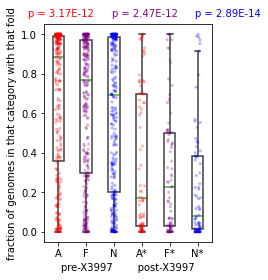

In [41]:
data1 = [(x2oxy[x]['aerobe'] / 1630) for x in preO2x]
data2 = [(x2oxy[x]['facultative'] / 394) for x in preO2x]
data3 = [(x2oxy[x]['anaerobe'] / 1099) for x in preO2x]

data4 = [(x2oxy[x]['aerobe'] / 1630) for x in postO2x]
data5 = [(x2oxy[x]['facultative'] / 394) for x in postO2x]
data6 = [(x2oxy[x]['anaerobe'] / 1099) for x in postO2x]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)

# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data4)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='red')

statistic, p_value = mannwhitneyu(data2, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.6, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')

statistic, p_value = mannwhitneyu(data3, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(1.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='blue')
###


# Add labels and title
plt.ylabel('fraction of genomes in that category with that fold')
plt.xlabel('pre-X3997        post-X3997')

# plt.savefig('aerobe_boxplot_fold_3997.png', dpi=300, bbox_inches = 'tight')
plt.show()


## pre/post with Group1/2

In [42]:
group1 = {'3997', '1', '4011', '253', '7574', '875', '206', '3016', '328', '2486', '212', '148', '2002', '325', '4952', '218', '184', '7577', '2005', '2007', '4953', '7501', '7584', '7579', '297', '2492', '7523', '101', '141', '7544', '109', '2003', '2004', '602', '330', '304', '327'}

In [43]:
group2 = set()
for x in x2foAveNONE.keys():
    if x not in group1:
        group2.add(x)

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


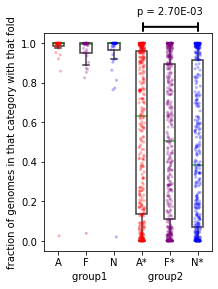

In [44]:
data1 = [(x2oxy[x]['aerobe'] / 1630) for x in group1]
data2 = [(x2oxy[x]['facultative'] / 394) for x in group1]
data3 = [(x2oxy[x]['anaerobe'] / 1099) for x in group1]

data4 = [(x2oxy[x]['aerobe'] / 1630) for x in group2]
data5 = [(x2oxy[x]['facultative'] / 394) for x in group2]
data6 = [(x2oxy[x]['anaerobe'] / 1099) for x in group2]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)

# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data4, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.75, 1.1), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.58, 1.03), xytext=(0.93, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('fraction of genomes in that category with that fold')
plt.xlabel('group1             group2')

# plt.savefig('aerobe_boxplot_fold_group12.png', dpi=300, bbox_inches = 'tight')
plt.show()


## pre/post with O2rxnFrac

In [45]:
x2O2rxnFrac = csv2dict('../data/assets/xgroup2/xgroup2O2rxnFrac.csv')

In [46]:
x2O2rxnFrac

{'7553': 0.0,
 '2487': 0.0625,
 '147': 0.0,
 '2011': 0.018518518518518517,
 '4048': 0.3333333333333333,
 '136': 0.23529411764705882,
 '2493': 0.0,
 '4004': 0.0,
 '217': 0.4583333333333333,
 '210': 0.16666666666666666,
 '911': 0.0,
 '3847': 0.0,
 '133': 0.0,
 '313': 0.0,
 '881': 0.5,
 '7514': 0.34375,
 '131': 0.047619047619047616,
 '7550': 0.0,
 '3997': 0.0,
 '603': 1.0,
 '4335': 0.2,
 '300': 0.0,
 '268': 0.17647058823529413,
 '231': 0.38461538461538464,
 '302': 0.25,
 '2012': 0.7142857142857143,
 '2006': 0.0196078431372549,
 '323': 0.15178571428571427,
 '7558': 0.0,
 '275': 0.0,
 '69': 0.0,
 '139': 0.0,
 '1': 0.21794871794871795,
 '6': 0.25,
 '708': 0.0,
 '257': 0.6363636363636364,
 '7540': 0.0,
 '3740': 0.2222222222222222,
 '331': 0.24390243902439024,
 '7568': 0.0,
 '246': 0.0,
 '4011': 0.028037383177570093,
 '4022': 0.0,
 '2484': 0.009433962264150943,
 '3994': 1.0,
 '209': 0.25,
 '253': 0.0,
 '7586': 0.0,
 '7549': 0.0,
 '6174': 1.0,
 '4159': 0.5,
 '12': 0.09774436090225563,
 '7589': 

In [47]:
noOxyDict = {x: x2O2rxnFrac[x] == 0.0 for x in x2O2rxnFrac.keys()}
noOxy = [key for key, value in noOxyDict.items() if value]
withOxyDict = {x: x2O2rxnFrac[x] > 0 for x in x2O2rxnFrac.keys()}
withOxy = [key for key, value in withOxyDict.items() if value]

In [48]:
len(withOxy), len(noOxy)

(155, 242)

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


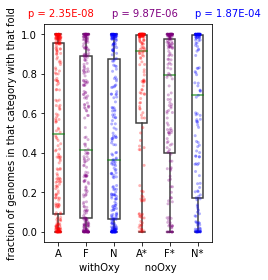

In [49]:
data1 = [(x2oxy[x]['aerobe'] / 1630) for x in noOxy]
data2 = [(x2oxy[x]['facultative'] / 394) for x in noOxy]
data3 = [(x2oxy[x]['anaerobe'] / 1099) for x in noOxy]

data4 = [(x2oxy[x]['aerobe'] / 1630) for x in withOxy]
data5 = [(x2oxy[x]['facultative'] / 394) for x in withOxy]
data6 = [(x2oxy[x]['anaerobe'] / 1099) for x in withOxy]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)

# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data4)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='red')

statistic, p_value = mannwhitneyu(data2, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.6, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')

statistic, p_value = mannwhitneyu(data3, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(1.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='blue')
###


# Add labels and title
plt.ylabel('fraction of genomes in that category with that fold')
plt.xlabel('withOxy        noOxy')

# plt.savefig('aerobe_boxplot_fold_withOxy_noOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()


### what about O2 only (n=17) vs. else?

In [50]:
newO2only = {'228', '241', '262', '3115', '3249', '3281', '3456', '3579', '3752', '3843', '3994', '4160', '557', '603', '6174', '620', '867'}
len(newO2only)

17

In [51]:
others = set()
for x in x2foAveNONE.keys():
    if x not in newO2only:
        others.add(x)

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


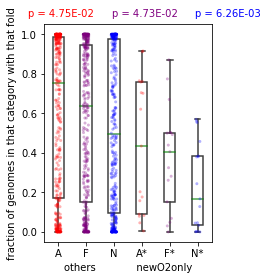

In [52]:
data1 = [(x2oxy[x]['aerobe'] / 1630) for x in others]
data2 = [(x2oxy[x]['facultative'] / 394) for x in others]
data3 = [(x2oxy[x]['anaerobe'] / 1099) for x in others]

data4 = [(x2oxy[x]['aerobe'] / 1630) for x in newO2only]
data5 = [(x2oxy[x]['facultative'] / 394) for x in newO2only]
data6 = [(x2oxy[x]['anaerobe'] / 1099) for x in newO2only]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)

# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data4)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='red')

statistic, p_value = mannwhitneyu(data2, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.6, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')

statistic, p_value = mannwhitneyu(data3, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(1.1, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='blue')
###


# Add labels and title
plt.ylabel('fraction of genomes in that category with that fold')
plt.xlabel('others             newO2only')

# plt.savefig('aerobe_boxplot_1b.png', dpi=300, bbox_inches = 'tight')
plt.show()


# plots (genomes)

In [53]:
x2oxy['2003']

# only look at 3123 (3350-157-70) annotated genomes (157 annotated genomes NOT in our ~62000 genomes set)
# only look at 397 folds
# genome2x[genome] = {'X1': #hit, 'X2': #hit}

{'aerobe': 1630, 'anaerobe': 1099, 'facultative': 394, 'unknown': 59168}

In [54]:
1630 + 1099 + 394

3123

In [56]:
genome2x = csv2dict('../genome2x_bac_aerobe.csv')
print(len(genome2x))  # 3158 * 397

3158


In [57]:
aSet = set()
for g in aerobeGenomes:  # 1711 genomes
    if g in genome2x.keys():  
        for x in x2foAveNONE.keys():
            if genome2x[g][x] > 0:  # fold exist in this genome
                aSet.add(g)
                
nSet = set()
for g in anaerobeGenomes:  # 1187 genomes
    if g in genome2x.keys():  
        for x in x2foAveNONE.keys():
            if genome2x[g][x] > 0:  # fold exist in this genome
                nSet.add(g)
                
fSet = set()
for g in facultativeGenomes:  # 417 genomes
    if g in genome2x.keys():  
        for x in x2foAveNONE.keys():
            if genome2x[g][x] > 0:  # fold exist in this genome
                fSet.add(g)

In [58]:
len(aSet), len(nSet), len(fSet)

(1644, 1105, 409)

In [59]:
check = csv2dict('check2003.csv')
checkA = set(check['aerobe'])
checkF = set(check['facultative'])
checkN = set(check['anaerobe'])
print(len(checkA))
print(len(checkF))
print(len(checkN))

duplicate = aSet - checkA | nSet - checkN | fSet - checkF
print(len(duplicate))

1630
394
1099
35


In [60]:
for g in duplicate:
    genome2x.pop(g)
print(len(genome2x))  # should print '3123'

3123


## pre/post with 3997

In [61]:
a_missing = set()
aerobe2frac = {}
a_rossmann = []
for g in aerobeGenomes:  # 1711 genomes
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        a_missing.add(g)
    
    else:
        frac = {'pre3997': 0, 'post3997': 0}
        for x in preO2x:  # 305 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['pre3997'] += 1
                
            if x == '2003':
                a_rossmann.append(genome2x[g][x])
        
        for x in postO2x:  # 92 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['post3997'] += 1
        aerobe2frac[g] = frac

In [62]:
len(a_rossmann), len(aerobe2frac), len(a_missing)  # 1630

(1630, 1630, 81)

In [63]:
n_missing = set()
anaerobe2frac = {}
n_rossmann = []
for g in anaerobeGenomes:
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        n_missing.add(g)
    
    else:
        frac = {'pre3997': 0, 'post3997': 0}
        for x in preO2x:  # 305 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['pre3997'] += 1
        
            if x == '2003':
                n_rossmann.append(genome2x[g][x])
                
        for x in postO2x:  # 92 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['post3997'] += 1
        anaerobe2frac[g] = frac

In [64]:
len(n_rossmann), len(anaerobe2frac), len(n_missing)

(1099, 1099, 88)

In [65]:
f_missing = set()
facultative2frac = {}
f_rossmann = []
for g in facultativeGenomes:
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        f_missing.add(g)
    
    else:
        frac = {'pre3997': 0, 'post3997': 0}
        for x in preO2x:  # 305 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['pre3997'] += 1
        
            if x == '2003':
                f_rossmann.append(genome2x[g][x])
                
        for x in postO2x:  # 92 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['post3997'] += 1
        facultative2frac[g] = frac

In [66]:
len(f_rossmann), len(facultative2frac), len(f_missing)

(394, 394, 23)

## pre/post with Group1/2

In [67]:
a_missing = set()
aerobe2frac2 = {}
for g in aerobeGenomes:  # 1711 genomes
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        a_missing.add(g)
    
    else:
        frac = {'group1': 0, 'group2': 0}
        for x in group1:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group1'] += 1
        
        for x in group2:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group2'] += 1
        aerobe2frac2[g] = frac

In [68]:
len(aerobe2frac2), len(a_missing)

(1630, 81)

In [69]:
n_missing = set()
anaerobe2frac2 = {}
for g in anaerobeGenomes:
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        n_missing.add(g)
    
    else:
        frac = {'group1': 0, 'group2': 0}
        for x in group1:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group1'] += 1
        
        for x in group2:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group2'] += 1
        anaerobe2frac2[g] = frac

In [70]:
len(anaerobe2frac2), len(n_missing)

(1099, 88)

In [71]:
f_missing = set()
facultative2frac2 = {}
for g in facultativeGenomes:
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        f_missing.add(g)
    
    else:
        frac = {'group1': 0, 'group2': 0}
        for x in group1:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group1'] += 1
        
        for x in group2:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['group2'] += 1
        facultative2frac2[g] = frac

In [72]:
len(facultative2frac), len(f_missing)

(394, 23)

## pre/post with O2rxnFrac

In [73]:
len(withOxy), len(noOxy)

(155, 242)

In [74]:
a_missing = set()
aerobe2frac3 = {}
for g in aerobeGenomes:  # 1711 genomes
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        a_missing.add(g)
    
    else:
        frac = {'noOxy': 0, 'withOxy': 0}
        for x in noOxy:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['noOxy'] += 1
        
        for x in withOxy:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['withOxy'] += 1
        aerobe2frac3[g] = frac

In [75]:
len(aerobe2frac3), len(a_missing)

(1630, 81)

In [76]:
n_missing = set()
anaerobe2frac3 = {}
for g in anaerobeGenomes:  # 1711 genomes
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        n_missing.add(g)
    
    else:
        frac = {'noOxy': 0, 'withOxy': 0}
        for x in noOxy:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['noOxy'] += 1
        
        for x in withOxy:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['withOxy'] += 1
        anaerobe2frac3[g] = frac

In [77]:
len(anaerobe2frac3), len(n_missing)

(1099, 88)

In [78]:
f_missing = set()
facultative2frac3 = {}
for g in facultativeGenomes:  # 1711 genomes
    
    # Josh genome not in ~62000 genomes 
    if g not in genome2x.keys():  
        f_missing.add(g)
    
    else:
        frac = {'noOxy': 0, 'withOxy': 0}
        for x in noOxy:  # 37 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['noOxy'] += 1
        
        for x in withOxy:  # 360 folds
            if genome2x[g][x] > 0:  # fold exist in this genome
                frac['withOxy'] += 1
        facultative2frac3[g] = frac

In [79]:
len(facultative2frac3), len(f_missing)

(394, 23)

# do aerobes have more folds?

In [80]:
[aerobe2frac[g]['pre3997'] for g in aerobe2frac.keys()]

[224,
 209,
 205,
 216,
 196,
 196,
 199,
 219,
 159,
 195,
 206,
 212,
 226,
 139,
 222,
 236,
 194,
 200,
 213,
 189,
 174,
 205,
 176,
 134,
 219,
 221,
 191,
 226,
 213,
 221,
 203,
 187,
 200,
 230,
 220,
 220,
 216,
 197,
 187,
 233,
 217,
 237,
 226,
 212,
 194,
 203,
 226,
 214,
 223,
 220,
 230,
 218,
 207,
 221,
 199,
 198,
 204,
 167,
 194,
 235,
 222,
 208,
 209,
 228,
 190,
 237,
 210,
 225,
 178,
 225,
 210,
 190,
 214,
 213,
 212,
 144,
 215,
 210,
 193,
 204,
 168,
 214,
 208,
 222,
 224,
 209,
 219,
 202,
 191,
 223,
 216,
 178,
 216,
 205,
 213,
 215,
 212,
 177,
 223,
 196,
 222,
 206,
 167,
 193,
 218,
 206,
 220,
 173,
 213,
 165,
 225,
 236,
 196,
 220,
 202,
 205,
 211,
 205,
 197,
 231,
 199,
 210,
 196,
 192,
 201,
 215,
 198,
 170,
 226,
 224,
 214,
 229,
 209,
 228,
 223,
 197,
 207,
 233,
 161,
 136,
 205,
 202,
 201,
 193,
 133,
 210,
 200,
 221,
 211,
 226,
 233,
 224,
 206,
 231,
 229,
 227,
 206,
 206,
 198,
 216,
 208,
 219,
 199,
 229,
 214,
 220,
 213

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


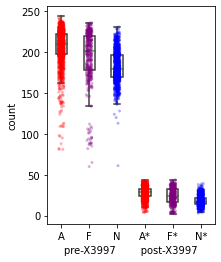

In [81]:
data1 = [aerobe2frac[g]['pre3997'] for g in aerobe2frac.keys()]
data2 = [facultative2frac[g]['pre3997'] for g in facultative2frac.keys()]
data3 = [anaerobe2frac[g]['pre3997'] for g in anaerobe2frac.keys()]
data4 = [aerobe2frac[g]['post3997'] for g in aerobe2frac.keys()]
data5 = [facultative2frac[g]['post3997'] for g in facultative2frac.keys()]
data6 = [anaerobe2frac[g]['post3997'] for g in anaerobe2frac.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('count')
plt.xlabel('pre-X3997        post-X3997')

# plt.savefig('aerobe_boxplot_foldCount_X3997.png', dpi=300, bbox_inches = 'tight')
plt.show()


In [82]:
aerobe2frac2

{'GCF_002356095.1': {'group1': 36, 'group2': 226},
 'GCF_003050755.1': {'group1': 36, 'group2': 205},
 'GCA_018500005.1': {'group1': 35, 'group2': 194},
 'GCF_900110245.1': {'group1': 34, 'group2': 215},
 'GCF_900129445.1': {'group1': 36, 'group2': 186},
 'GCA_905479075.1': {'group1': 36, 'group2': 188},
 'GCF_004346205.1': {'group1': 36, 'group2': 180},
 'GCF_000166295.1': {'group1': 36, 'group2': 209},
 'GCF_000159435.1': {'group1': 33, 'group2': 137},
 'GCF_002287505.1': {'group1': 35, 'group2': 175},
 'GCF_002797855.1': {'group1': 36, 'group2': 184},
 'GCF_000420025.1': {'group1': 36, 'group2': 202},
 'GCF_000321045.1': {'group1': 36, 'group2': 226},
 'GCF_001180165.1': {'group1': 31, 'group2': 118},
 'GCF_000421645.1': {'group1': 36, 'group2': 220},
 'GCF_000478275.1': {'group1': 36, 'group2': 237},
 'GCA_003243255.1': {'group1': 34, 'group2': 193},
 'GCA_017745215.1': {'group1': 35, 'group2': 195},
 'GCF_000425225.1': {'group1': 36, 'group2': 205},
 'GCF_001403775.1': {'group1': 

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


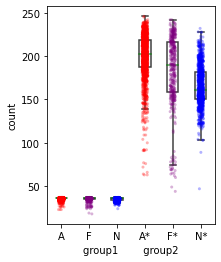

In [83]:
data1 = [aerobe2frac2[g]['group1'] for g in aerobe2frac2.keys()]
data2 = [facultative2frac2[g]['group1'] for g in facultative2frac2.keys()]
data3 = [anaerobe2frac2[g]['group1'] for g in anaerobe2frac2.keys()]
data4 = [aerobe2frac2[g]['group2'] for g in aerobe2frac2.keys()]
data5 = [facultative2frac2[g]['group2'] for g in facultative2frac2.keys()]
data6 = [anaerobe2frac2[g]['group2'] for g in anaerobe2frac2.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('count')
plt.xlabel('group1        group2')

# plt.savefig('aerobe_boxplot_foldCount_group12.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


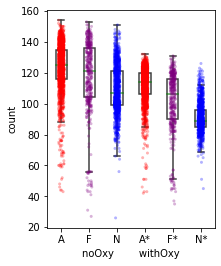

In [84]:
data1 = [aerobe2frac3[g]['noOxy'] for g in aerobe2frac3.keys()]
data2 = [facultative2frac3[g]['noOxy'] for g in facultative2frac3.keys()]
data3 = [anaerobe2frac3[g]['noOxy'] for g in anaerobe2frac3.keys()]
data4 = [aerobe2frac3[g]['withOxy'] for g in aerobe2frac3.keys()]
data5 = [facultative2frac3[g]['withOxy'] for g in facultative2frac3.keys()]
data6 = [anaerobe2frac3[g]['withOxy'] for g in anaerobe2frac3.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('count')
plt.xlabel('noOxy        withOxy')

# plt.savefig('aerobe_boxplot_foldCount_noOxy_withOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()


# normalize by number of folds in each genome

## 3997

In [85]:
aerobe2frac

{'GCF_002356095.1': {'pre3997': 224, 'post3997': 38},
 'GCF_003050755.1': {'pre3997': 209, 'post3997': 32},
 'GCA_018500005.1': {'pre3997': 205, 'post3997': 24},
 'GCF_900110245.1': {'pre3997': 216, 'post3997': 33},
 'GCF_900129445.1': {'pre3997': 196, 'post3997': 26},
 'GCA_905479075.1': {'pre3997': 196, 'post3997': 28},
 'GCF_004346205.1': {'pre3997': 199, 'post3997': 17},
 'GCF_000166295.1': {'pre3997': 219, 'post3997': 26},
 'GCF_000159435.1': {'pre3997': 159, 'post3997': 11},
 'GCF_002287505.1': {'pre3997': 195, 'post3997': 15},
 'GCF_002797855.1': {'pre3997': 206, 'post3997': 14},
 'GCF_000420025.1': {'pre3997': 212, 'post3997': 26},
 'GCF_000321045.1': {'pre3997': 226, 'post3997': 36},
 'GCF_001180165.1': {'pre3997': 139, 'post3997': 10},
 'GCF_000421645.1': {'pre3997': 222, 'post3997': 34},
 'GCF_000478275.1': {'pre3997': 236, 'post3997': 37},
 'GCA_003243255.1': {'pre3997': 194, 'post3997': 33},
 'GCA_017745215.1': {'pre3997': 200, 'post3997': 30},
 'GCF_000425225.1': {'pre399

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


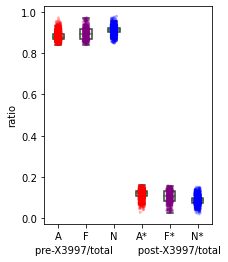

In [86]:
data1 = [aerobe2frac[g]['pre3997'] / (aerobe2frac[g]['pre3997'] + aerobe2frac[g]['post3997']) for g in aerobe2frac.keys()]
data2 = [facultative2frac[g]['pre3997'] / (facultative2frac[g]['pre3997'] + facultative2frac[g]['post3997']) for g in facultative2frac.keys()]
data3 = [anaerobe2frac[g]['pre3997'] / (anaerobe2frac[g]['pre3997'] + anaerobe2frac[g]['post3997']) for g in anaerobe2frac.keys()]

data4 = [aerobe2frac[g]['post3997'] / (aerobe2frac[g]['pre3997'] + aerobe2frac[g]['post3997']) for g in aerobe2frac.keys()]
data5 = [facultative2frac[g]['post3997'] / (facultative2frac[g]['pre3997'] + facultative2frac[g]['post3997']) for g in facultative2frac.keys()]
data6 = [anaerobe2frac[g]['post3997'] / (anaerobe2frac[g]['pre3997'] + anaerobe2frac[g]['post3997']) for g in anaerobe2frac.keys()]


# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('ratio')
plt.xlabel('pre-X3997/total        post-X3997/total')

# plt.savefig('aerobe_boxplot_genomeRatio_X3997.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


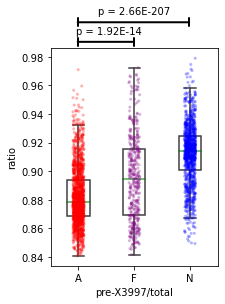

In [87]:
data1 = [aerobe2frac[g]['pre3997'] / (aerobe2frac[g]['pre3997'] + aerobe2frac[g]['post3997']) for g in aerobe2frac.keys()]
data2 = [facultative2frac[g]['pre3997'] / (facultative2frac[g]['pre3997'] + facultative2frac[g]['post3997']) for g in facultative2frac.keys()]
data3 = [anaerobe2frac[g]['pre3997'] / (anaerobe2frac[g]['pre3997'] + anaerobe2frac[g]['post3997']) for g in anaerobe2frac.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white
    
# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data2)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data1, data3)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('ratio')
plt.xlabel('pre-X3997/total')

# plt.savefig('aerobe_boxplot_genomeRatio_X3997_pre.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


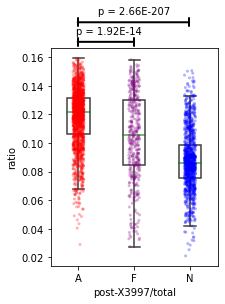

In [88]:
data4 = [aerobe2frac[g]['post3997'] / (aerobe2frac[g]['pre3997'] + aerobe2frac[g]['post3997']) for g in aerobe2frac.keys()]
data5 = [facultative2frac[g]['post3997'] / (facultative2frac[g]['pre3997'] + facultative2frac[g]['post3997']) for g in facultative2frac.keys()]
data6 = [anaerobe2frac[g]['post3997'] / (anaerobe2frac[g]['pre3997'] + anaerobe2frac[g]['post3997']) for g in anaerobe2frac.keys()]


# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data4 + data5 + data6
groups = ['A'] * len(data4) + ['F'] * len(data5) + ['N'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data4, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data4, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('ratio')
plt.xlabel('post-X3997/total')

# plt.savefig('aerobe_boxplot_genomeRatio_X3997_post.png', dpi=300, bbox_inches = 'tight')
plt.show()


## group 1 vs 2

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


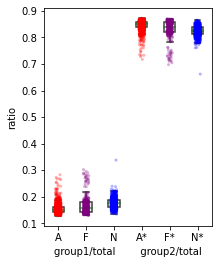

In [89]:
data1 = [aerobe2frac2[g]['group1'] / (aerobe2frac2[g]['group1'] + aerobe2frac2[g]['group2']) for g in aerobe2frac2.keys()]
data2 = [facultative2frac2[g]['group1'] / (facultative2frac2[g]['group1'] + facultative2frac2[g]['group2']) for g in facultative2frac2.keys()]
data3 = [anaerobe2frac2[g]['group1'] / (anaerobe2frac2[g]['group1'] + anaerobe2frac2[g]['group2']) for g in anaerobe2frac2.keys()]

data4 = [aerobe2frac2[g]['group2'] / (aerobe2frac2[g]['group1'] + aerobe2frac2[g]['group2']) for g in aerobe2frac2.keys()]
data5 = [facultative2frac2[g]['group2'] / (facultative2frac2[g]['group1'] + facultative2frac2[g]['group2']) for g in facultative2frac2.keys()]
data6 = [anaerobe2frac2[g]['group2'] / (anaerobe2frac2[g]['group1'] + anaerobe2frac2[g]['group2']) for g in anaerobe2frac2.keys()]


# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('ratio')
plt.xlabel('group1/total        group2/total')

# plt.savefig('aerobe_boxplot_genomeRatio_group12.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


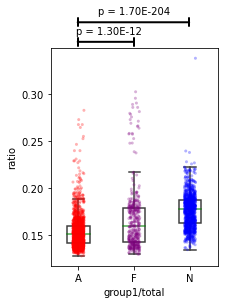

In [90]:
data1 = [aerobe2frac2[g]['group1'] / (aerobe2frac2[g]['group1'] + aerobe2frac2[g]['group2']) for g in aerobe2frac2.keys()]
data2 = [facultative2frac2[g]['group1'] / (facultative2frac2[g]['group1'] + facultative2frac2[g]['group2']) for g in facultative2frac2.keys()]
data3 = [anaerobe2frac2[g]['group1'] / (anaerobe2frac2[g]['group1'] + anaerobe2frac2[g]['group2']) for g in anaerobe2frac2.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data2)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data1, data3)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('ratio')
plt.xlabel('group1/total')

# plt.savefig('aerobe_boxplot_genomeRatio_group12_group1.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


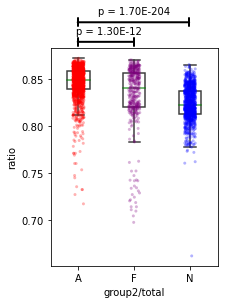

In [91]:
data4 = [aerobe2frac2[g]['group2'] / (aerobe2frac2[g]['group1'] + aerobe2frac2[g]['group2']) for g in aerobe2frac2.keys()]
data5 = [facultative2frac2[g]['group2'] / (facultative2frac2[g]['group1'] + facultative2frac2[g]['group2']) for g in facultative2frac2.keys()]
data6 = [anaerobe2frac2[g]['group2'] / (anaerobe2frac2[g]['group1'] + anaerobe2frac2[g]['group2']) for g in anaerobe2frac2.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data4 + data5 + data6
groups = ['A'] * len(data4) + ['F'] * len(data5) + ['N'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('ratio')
plt.xlabel('group2/total')


###
# U-test
statistic, p_value = mannwhitneyu(data4, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data4, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# plt.savefig('aerobe_boxplot_genomeRatio_group12_group2.png', dpi=300, bbox_inches = 'tight')
plt.show()


### who is that one genome at the bottom of anaerobes?

In [92]:
for key in anaerobe2frac2.keys():
    if anaerobe2frac2[key]['group2'] / (anaerobe2frac2[key]['group1'] + anaerobe2frac2[key]['group2']) < 0.7:
        print(key, anaerobe2frac2[key], anaerobe2frac2[key]['group2']/(anaerobe2frac2[key]['group1'] + anaerobe2frac2[key]['group2']))

GCA_000147015.1 {'group1': 24, 'group2': 47} 0.6619718309859155


In [93]:
# GCA_000147015.1: Candidatus Zinderia insecticola CARI - endosymbiont of Clastoptera arizonana

# Warning: genome length too small
# Status: RefSeq GCF_000147015.1 is suppressed
# This record was removed by RefSeq staff. Please contact info@ncbi.nlm.nih.gov for further details. 
# Reason: annotation


## withOxy vs. noOxy

/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


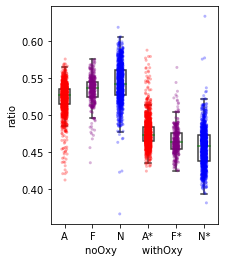

In [94]:
data1 = [aerobe2frac3[g]['noOxy'] / (aerobe2frac3[g]['noOxy'] + aerobe2frac3[g]['withOxy']) for g in aerobe2frac3.keys()]
data2 = [facultative2frac3[g]['noOxy'] / (facultative2frac3[g]['noOxy'] + facultative2frac3[g]['withOxy'])for g in facultative2frac3.keys()]
data3 = [anaerobe2frac3[g]['noOxy'] / (anaerobe2frac3[g]['noOxy'] + anaerobe2frac3[g]['withOxy'])for g in anaerobe2frac3.keys()]
data4 = [aerobe2frac3[g]['withOxy'] / (aerobe2frac3[g]['noOxy'] + aerobe2frac3[g]['withOxy'])for g in aerobe2frac3.keys()]
data5 = [facultative2frac3[g]['withOxy'] / (facultative2frac3[g]['noOxy'] + facultative2frac3[g]['withOxy'])for g in facultative2frac3.keys()]
data6 = [anaerobe2frac3[g]['withOxy'] / (anaerobe2frac3[g]['noOxy'] + anaerobe2frac3[g]['withOxy'])for g in anaerobe2frac3.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3, data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3 + data4 + data5 + data6
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3) + ['A*'] * len(data4) + ['F*'] * len(data5) + ['N*'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue', 'red', 'purple', 'blue'], size=3, alpha=0.3)

# Add labels and title
plt.ylabel('ratio')
plt.xlabel('noOxy        withOxy')

# plt.savefig('aerobe_boxplot_genomeRatio_noOxy_withOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


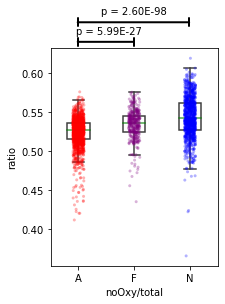

In [95]:
data1 = [aerobe2frac3[g]['noOxy'] / (aerobe2frac3[g]['noOxy'] + aerobe2frac3[g]['withOxy']) for g in aerobe2frac3.keys()]
data2 = [facultative2frac3[g]['noOxy'] / (facultative2frac3[g]['noOxy'] + facultative2frac3[g]['withOxy'])for g in facultative2frac3.keys()]
data3 = [anaerobe2frac3[g]['noOxy'] / (anaerobe2frac3[g]['noOxy'] + anaerobe2frac3[g]['withOxy'])for g in anaerobe2frac3.keys()]


# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data1, data2, data3], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data1 + data2 + data3
groups = ['A'] * len(data1) + ['F'] * len(data2) + ['N'] * len(data3)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data1, data2)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data1, data3)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('ratio')
plt.xlabel('noOxy/total')

# plt.savefig('aerobe_boxplot_genomeRatio_noOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()


/Users/tseamuscorlett/opt/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


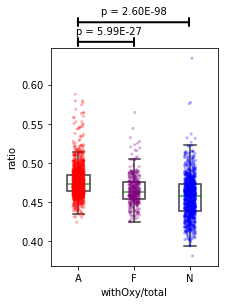

In [96]:
data4 = [aerobe2frac3[g]['withOxy'] / (aerobe2frac3[g]['noOxy'] + aerobe2frac3[g]['withOxy'])for g in aerobe2frac3.keys()]
data5 = [facultative2frac3[g]['withOxy'] / (facultative2frac3[g]['noOxy'] + facultative2frac3[g]['withOxy'])for g in facultative2frac3.keys()]
data6 = [anaerobe2frac3[g]['withOxy'] / (anaerobe2frac3[g]['noOxy'] + anaerobe2frac3[g]['withOxy'])for g in anaerobe2frac3.keys()]

# boxplot
fig, ax = plt.subplots(figsize=(3, 4))
boxplot = sns.boxplot(data=[data4, data5, data6], width=0.4, ax=ax, medianprops=dict(color="green", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker=""))
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.0))  # 0.0 to make them all white


# Combine the data and create a list to indicate the group for each data point
combined_data = data4 + data5 + data6
groups = ['A'] * len(data4) + ['F'] * len(data5) + ['N'] * len(data6)
# Create the strip plot using seaborn
sns.stripplot(groups, combined_data, jitter=True, palette=['red', 'purple', 'blue'], size=3, alpha=0.3)


###
# U-test
statistic, p_value = mannwhitneyu(data4, data5)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.35, 1.08), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

statistic, p_value = mannwhitneyu(data4, data6)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.5, 1.17), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

# brackets
ax.annotate('', xy=(0.15, 1.03), xytext=(0.51, 1.03), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
ax.annotate('', xy=(0.15, 1.12), xytext=(0.84, 1.12), xycoords='axes fraction',
           textcoords='axes fraction', arrowprops=dict(arrowstyle='|-|, widthA=0.4, widthB=0.4, angleA=0, angleB=0', lw=2, color='k'))
###


# Add labels and title
plt.ylabel('ratio')
plt.xlabel('withOxy/total')

# plt.savefig('aerobe_boxplot_genomeRatio_withOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()

### who is that one genome at the top of anaerobes?

In [97]:
len(withOxy), len(noOxy)

(155, 242)

In [98]:
for key in anaerobe2frac3.keys():
    if anaerobe2frac3[key]['withOxy'] / (anaerobe2frac3[key]['noOxy'] + anaerobe2frac3[key]['withOxy']) > 0.55:
        print(key, anaerobe2frac3[key], anaerobe2frac3[key]['withOxy']/(anaerobe2frac3[key]['noOxy'] + anaerobe2frac3[key]['withOxy']))

GCA_000147015.1 {'noOxy': 26, 'withOxy': 45} 0.6338028169014085
GCA_017632825.1 {'noOxy': 56, 'withOxy': 76} 0.5757575757575758
GCA_005768725.1 {'noOxy': 71, 'withOxy': 97} 0.5773809523809523


In [99]:
# GCA_000147015.1: Candidatus Zinderia insecticola CARI - endosymbiont of Clastoptera arizonana
# GCA_005768725.1: Blastochloris viridis – anoxygenic phototroph (photosynthesis w/o O2 production); purple bacteria
# GCA_017632825.1: Prevotella sp. (oral, vaginal, and gut microbiota often recovered from anaerobic infections)


# Warning: genome length too small
# Status: RefSeq GCF_000147015.1 is suppressed
# This record was removed by RefSeq staff. Please contact info@ncbi.nlm.nih.gov for further details. 
# Reason: annotation


# consider hit counts?

In [101]:
# also look at ALL 2230 X-groups

genome2xfull = csv2dict('../genome2x_bac_aerobeFull.csv')
print(len(genome2xfull))  # 3158 * 2230

aSet = set()
for g in aerobeGenomes:  # 1711 genomes
    if g in genome2xfull.keys():  
        for x in x2foAveNONE.keys():
            if genome2xfull[g][x] > 0:  # fold exist in this genome
                aSet.add(g)
                
nSet = set()
for g in anaerobeGenomes:  # 1187 genomes
    if g in genome2xfull.keys():  
        for x in x2foAveNONE.keys():
            if genome2xfull[g][x] > 0:  # fold exist in this genome
                nSet.add(g)
                
fSet = set()
for g in facultativeGenomes:  # 417 genomes
    if g in genome2xfull.keys():  
        for x in x2foAveNONE.keys():
            if genome2xfull[g][x] > 0:  # fold exist in this genome
                fSet.add(g)
print(len(aSet), len(nSet), len(fSet))

check = csv2dict('check2003.csv')
checkA = set(check['aerobe'])
checkF = set(check['facultative'])
checkN = set(check['anaerobe'])
print(len(checkA), len(checkN), len(checkF))

duplicate = aSet - checkA | nSet - checkN | fSet - checkF
print(len(duplicate))

for g in duplicate:
    genome2xfull.pop(g)
print(len(genome2xfull))  # should print '3123'

3158
1644 1105 409
1630 1099 394
35
3123


In [102]:
genome2xfull['GCA_000007325.1']

{'2004': 160,
 '101': 64,
 '148': 8,
 '7577': 18,
 '3016': 16,
 '304': 78,
 '244': 8,
 '1': 42,
 '7523': 29,
 '7579': 7,
 '2003': 102,
 '2484': 45,
 '7604': 0,
 '207': 3,
 '4040': 2,
 '2': 26,
 '102': 16,
 '230': 7,
 '138': 1,
 '377': 3,
 '4070': 1,
 '212': 16,
 '3010': 1,
 '1075': 40,
 '243': 0,
 '2485': 11,
 '109': 29,
 '258': 0,
 '206': 12,
 '2002': 76,
 '2005': 20,
 '310': 2,
 '205': 0,
 '3826': 0,
 '330': 7,
 '7543': 2,
 '325': 12,
 '2007': 79,
 '144': 0,
 '235': 3,
 '294': 1,
 '225': 13,
 '802': 0,
 '316': 4,
 '131': 4,
 '2487': 5,
 '5': 4,
 '11': 5,
 '5069': 0,
 '236': 1,
 '187': 0,
 '129': 2,
 '298': 2,
 '12': 2,
 '7512': 18,
 '2488': 7,
 '327': 13,
 '3697': 0,
 '302': 1,
 '301': 10,
 '4002': 3,
 '7573': 10,
 '3892': 0,
 '3978': 0,
 '284': 1,
 '306': 4,
 '589': 1,
 '547': 0,
 '10': 13,
 '7581': 8,
 '222': 5,
 '4': 13,
 '73': 0,
 '227': 6,
 '7542': 0,
 '161': 1,
 '213': 19,
 '142': 1,
 '620': 2,
 '2492': 7,
 '7501': 2,
 '211': 2,
 '5051': 7,
 '4261': 5,
 '2486': 12,
 '650': 2,
 

In [103]:
# for each genome, calculate (# oxy fold hits / all fold hits)

In [104]:
aerobe2hits_3997 = {}
anaerobe2hits_3997 = {}
facultative2hits_3997 = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in postO2x:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_3997[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in postO2x:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_3997[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in postO2x:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_3997[g] = oxyHits / allHits
    
print(len(aerobe2hits_3997))

1630


In [105]:
aerobe2hits_3997

{'GCF_002356095.1': 0.023191246121182427,
 'GCF_003050755.1': 0.022049611626158858,
 'GCA_018500005.1': 0.019508057675996608,
 'GCF_900110245.1': 0.022315937445088738,
 'GCF_900129445.1': 0.020523005627275735,
 'GCA_905479075.1': 0.02679830747531735,
 'GCF_004346205.1': 0.018006148440931048,
 'GCF_000166295.1': 0.02319201995012469,
 'GCF_000159435.1': 0.018746338605741066,
 'GCF_002287505.1': 0.016831683168316833,
 'GCF_002797855.1': 0.010631644777986242,
 'GCF_000420025.1': 0.020465377067563777,
 'GCF_000321045.1': 0.028035367694630147,
 'GCF_001180165.1': 0.02211874272409779,
 'GCF_000421645.1': 0.019796682718031033,
 'GCF_000478275.1': 0.017158544955387784,
 'GCA_003243255.1': 0.021502590673575128,
 'GCA_017745215.1': 0.0230722525804493,
 'GCF_000425225.1': 0.026969292389853138,
 'GCF_001403775.1': 0.01597444089456869,
 'GCF_000162575.1': 0.022135416666666668,
 'GCF_001274595.1': 0.02132463622679378,
 'GCF_000699505.1': 0.010114632501685773,
 'GCF_000334405.1': 0.010526315789473684,

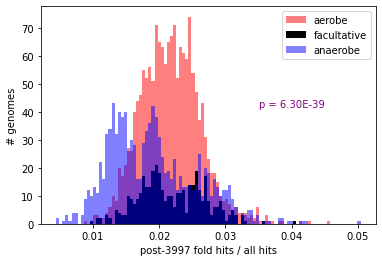

In [106]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_3997.values()), min(anaerobe2hits_3997.values()), min(facultative2hits_3997.values()))
max_val = max(max(aerobe2hits_3997.values()), max(anaerobe2hits_3997.values()), max(facultative2hits_3997.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_3997.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_3997.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_3997.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_3997.values()), list(anaerobe2hits_3997.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.75, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('post-3997 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_3997.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [107]:
aerobe2hits_g12 = {}
anaerobe2hits_g12 = {}
facultative2hits_g12 = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in group2:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_g12[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in group2:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_g12[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in group2:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_g12[g] = oxyHits / allHits
    
print(len(aerobe2hits_g12))

1630


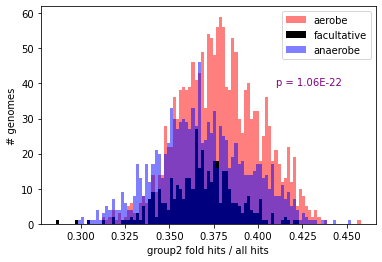

In [108]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_g12.values()), min(anaerobe2hits_g12.values()), min(facultative2hits_g12.values()))
max_val = max(max(aerobe2hits_g12.values()), max(anaerobe2hits_g12.values()), max(facultative2hits_g12.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_g12.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_g12.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_g12.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_g12.values()), list(anaerobe2hits_g12.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.80, 0.65), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('group2 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_g12.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [109]:
aerobe2hits_withOxyNoOxy = {}
anaerobe2hits_withOxyNoOxy = {}
facultative2hits_withOxyNoOxy = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxy:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_withOxyNoOxy[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxy:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_withOxyNoOxy[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxy:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_withOxyNoOxy[g] = oxyHits / allHits
    
print(len(aerobe2hits_withOxyNoOxy))

1630


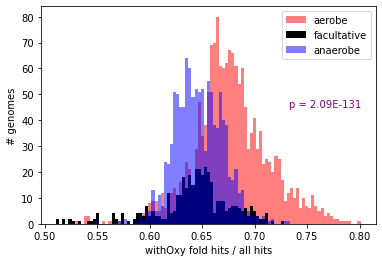

In [110]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_withOxyNoOxy.values()), min(anaerobe2hits_withOxyNoOxy.values()), min(facultative2hits_withOxyNoOxy.values()))
max_val = max(max(aerobe2hits_withOxyNoOxy.values()), max(anaerobe2hits_withOxyNoOxy.values()), max(facultative2hits_withOxyNoOxy.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyNoOxy.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyNoOxy.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyNoOxy.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyNoOxy.values()), list(anaerobe2hits_withOxyNoOxy.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxy fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyNoOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [111]:
newO2only = {'228',
 '241',
 '262',
 '3115',
 '3249',
 '3281',
 '3456',
 '3579',
 '3752',
 '3843',
 '3994',
 '4160',
 '557',
 '603',
 '6174',
 '620',
 '867'}

In [112]:
aerobe2hits_newO2only = {}
anaerobe2hits_newO2only = {}
facultative2hits_newO2only = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in newO2only:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_newO2only[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in newO2only:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_newO2only[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in newO2only:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_newO2only[g] = oxyHits / allHits
    
print(len(aerobe2hits_newO2only))

1630


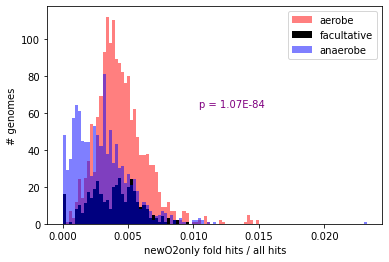

In [113]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_newO2only.values()), min(anaerobe2hits_newO2only.values()), min(facultative2hits_newO2only.values()))
max_val = max(max(aerobe2hits_newO2only.values()), max(anaerobe2hits_newO2only.values()), max(facultative2hits_newO2only.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_newO2only.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_newO2only.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_newO2only.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_newO2only.values()), list(anaerobe2hits_newO2only.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.55, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('newO2only fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_newO2only.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [114]:
NewDogOldTrick = {'146',
 '158',
 '192',
 '196',
 '2012',
 '257',
 '3207',
 '3697',
 '3777',
 '3960',
 '3978',
 '4024',
 '4025',
 '4028',
 '4046',
 '4048',
 '4110',
 '4159',
 '4229',
 '4272',
 '4294',
 '4983',
 '5039',
 '5100',
 '6',
 '608',
 '6166',
 '640',
 '66',
 '7',
 '7578',
 '881',
 '9',
 '914'}

In [115]:
mySet = newO2only | NewDogOldTrick

In [116]:
aerobe2hits_mySet = {}
anaerobe2hits_mySet = {}
facultative2hits_mySet = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in mySet:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_mySet[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in mySet:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_mySet[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in mySet:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_mySet[g] = oxyHits / allHits
    
print(len(aerobe2hits_mySet))

1630


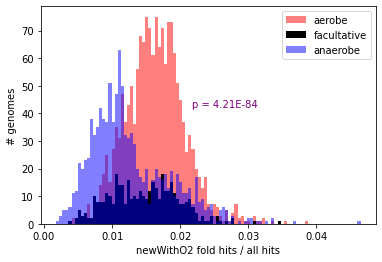

In [117]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_mySet.values()), min(anaerobe2hits_mySet.values()), min(facultative2hits_mySet.values()))
max_val = max(max(aerobe2hits_mySet.values()), max(anaerobe2hits_mySet.values()), max(facultative2hits_mySet.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_mySet.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_mySet.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_mySet.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_mySet.values()), list(anaerobe2hits_mySet.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.55, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('newWithO2 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_newWithO2.png', dpi=300, bbox_inches = 'tight')
plt.show()

### try withOxyNoOxy DIRECT

In [118]:
withOxyDIRECT = {'4052', '247', '146', '7', '187', '325', '6', '2484', '262', '2012', '4229', '10', '3156', '211', '331', '2485', '4033', '108', '5038', '5039', '221', '304', '3249', '4159', '107', '7577', '281', '149', '601', '603', '3115', '3016', '109', '4002', '2002', '2003', '131', '557', '228', '192', '867', '106', '4048', '881', '2004', '375', '217', '4110', '5069', '158', '3777', '209', '223', '3207', '136', '257', '231', '12', '179', '150', '4028', '640', '302', '3978', '620', '914', '633', '4160', '243', '101', '2486', '4294', '3752', '3687', '7574', '5', '244', '2007', '327', '7514', '6174', '6058', '278', '230', '4983', '11', '604', '205', '1', '241', '66'}
len(withOxyDIRECT), len(withOxy)

(91, 155)

In [119]:
aerobe2hits_withOxyDIRECT = {}
anaerobe2hits_withOxyDIRECT = {}
facultative2hits_withOxyDIRECT = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_withOxyDIRECT[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_withOxyDIRECT[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_withOxyDIRECT[g] = oxyHits / allHits
    
print(len(aerobe2hits_withOxyDIRECT))

1630


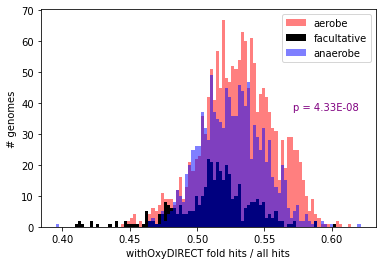

In [120]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_withOxyDIRECT.values()), min(anaerobe2hits_withOxyDIRECT.values()), min(facultative2hits_withOxyDIRECT.values()))
max_val = max(max(aerobe2hits_withOxyDIRECT.values()), max(anaerobe2hits_withOxyDIRECT.values()), max(facultative2hits_withOxyDIRECT.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyDIRECT.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyDIRECT.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyDIRECT.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyDIRECT.values()), list(anaerobe2hits_withOxyDIRECT.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxyDIRECT fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyDIRECT.png', dpi=300, bbox_inches = 'tight')
plt.show()

### well that's interesting... let's try INDIRECT

In [121]:
withOxyINDIRECT = {'4052', '7552', '1001', '4046', '4019', '247', '3456', '7561', '187', '325', '608', '10', '196', '2485', '4033', '5038', '221', '3994', '304', '301', '107', '7577', '149', '3740', '3016', '3579', '5100', '109', '4011', '323', '4002', '2002', '4', '9', '268', '4025', '2003', '315', '371', '4952', '2006', '3697', '6166', '867', '279', '3447', '236', '4335', '2004', '7584', '4194', '2005', '217', '2487', '5069', '7512', '223', '5084', '141', '7524', '136', '231', '179', '7542', '316', '222', '3843', '2011', '7510', '7525', '3281', '620', '3264', '503', '218', '914', '633', '129', '219', '213', '243', '101', '2486', '7567', '7574', '5', '3960', '244', '2007', '327', '7581', '206', '7578', '602', '6058', '7515', '278', '4272', '11', '604', '298', '205', '1', '7579', '210', '103', '4024'}
len(withOxyINDIRECT), len(withOxy)

(107, 155)

In [122]:
aerobe2hits_withOxyINDIRECT = {}
anaerobe2hits_withOxyINDIRECT = {}
facultative2hits_withOxyINDIRECT = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyINDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_withOxyINDIRECT[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyINDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_withOxyINDIRECT[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x in withOxyINDIRECT:
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_withOxyINDIRECT[g] = oxyHits / allHits
    
print(len(aerobe2hits_withOxyINDIRECT))

1630


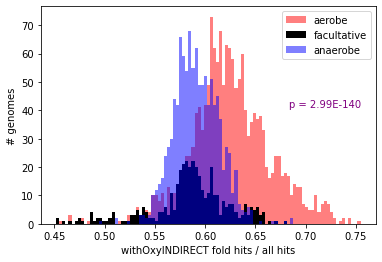

In [123]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_withOxyINDIRECT.values()), min(anaerobe2hits_withOxyINDIRECT.values()), min(facultative2hits_withOxyINDIRECT.values()))
max_val = max(max(aerobe2hits_withOxyINDIRECT.values()), max(anaerobe2hits_withOxyINDIRECT.values()), max(facultative2hits_withOxyINDIRECT.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyINDIRECT.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyINDIRECT.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyINDIRECT.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyINDIRECT.values()), list(anaerobe2hits_withOxyINDIRECT.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxyINDIRECT fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyINDIRECT.png', dpi=300, bbox_inches = 'tight')
plt.show()

### with Eukaryotes

In [124]:
genome2x_euk_Full = csv2dict('../genome2x_euk_Full.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../assets/genome2x_euk_Full.csv'

In [ ]:
genome2x_euk_Full['EP00704']

In [ ]:
euk2hits_withOxy = {}

for g in genome2x_euk_Full.keys():
    oxyHits = 0
    allHits = 0
    for x in genome2x_euk_Full[g]:
        if x in withOxy:
            oxyHits += genome2x_euk_Full[g][x]
        allHits += genome2x_euk_Full[g][x]
    euk2hits_withOxy[g] = oxyHits / allHits

In [ ]:
# both direct and indirect

min_val = min(min(aerobe2hits_withOxyNoOxy.values()), min(anaerobe2hits_withOxyNoOxy.values()), min(facultative2hits_withOxyNoOxy.values()))
max_val = max(max(aerobe2hits_withOxyNoOxy.values()), max(anaerobe2hits_withOxyNoOxy.values()), max(facultative2hits_withOxyNoOxy.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyNoOxy.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyNoOxy.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyNoOxy.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5)
plt.hist(euk2hits_withOxy.values(), bins=bins, color='green', label='eukaryotes', alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyNoOxy.values()), list(anaerobe2hits_withOxyNoOxy.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxy fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyNoOxy.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
euk2hits_withOxyDIRECT = {}

for g in genome2x_euk_Full.keys():
    oxyHits = 0
    allHits = 0
    for x in genome2x_euk_Full[g]:
        if x in withOxyDIRECT:
            oxyHits += genome2x_euk_Full[g][x]
        allHits += genome2x_euk_Full[g][x]
    euk2hits_withOxyDIRECT[g] = oxyHits / allHits

In [ ]:
# DIRECT

# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_withOxyDIRECT.values()), min(anaerobe2hits_withOxyDIRECT.values()), min(facultative2hits_withOxyDIRECT.values()))
max_val = max(max(aerobe2hits_withOxyDIRECT.values()), max(anaerobe2hits_withOxyDIRECT.values()), max(facultative2hits_withOxyDIRECT.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyDIRECT.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyDIRECT.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyDIRECT.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5)
plt.hist(euk2hits_withOxyDIRECT.values(), bins=bins, color='green', label='eukaryotes', alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyDIRECT.values()), list(anaerobe2hits_withOxyDIRECT.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxyDIRECT fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyDIRECT.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
euk2hits_withOxyINDIRECT = {}

for g in genome2x_euk_Full.keys():
    oxyHits = 0
    allHits = 0
    for x in genome2x_euk_Full[g]:
        if x in withOxyINDIRECT:
            oxyHits += genome2x_euk_Full[g][x]
        allHits += genome2x_euk_Full[g][x]
    euk2hits_withOxyINDIRECT[g] = oxyHits / allHits

In [ ]:
# INDIRECT

# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_withOxyINDIRECT.values()), min(anaerobe2hits_withOxyINDIRECT.values()), min(facultative2hits_withOxyINDIRECT.values()))
max_val = max(max(aerobe2hits_withOxyINDIRECT.values()), max(anaerobe2hits_withOxyINDIRECT.values()), max(facultative2hits_withOxyINDIRECT.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_withOxyINDIRECT.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_withOxyINDIRECT.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_withOxyINDIRECT.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5)
plt.hist(euk2hits_withOxyINDIRECT.values(), bins=bins, color='green', label='eukaryotes', alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_withOxyINDIRECT.values()), list(anaerobe2hits_withOxyINDIRECT.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('withOxyINDIRECT fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_withOxyINDIRECT.png', dpi=300, bbox_inches = 'tight')
plt.show()

# Oxygen detox

In [ ]:
# GO to KEGG website => search enzyme name => get all EC numbers

# SOD
'''
1.15.1.1
'''

# catalase
'''
1.11.1.6
1.11.1.21
'''

# peroxidase
'''
{'1.11.1.1',
'1.11.1.2',
'1.11.1.3',
'1.11.1.5',
'1.11.1.6',
'1.11.1.7',
'1.11.1.8',
'1.11.1.9',
'1.11.1.10',
'1.11.1.11',
'1.11.1.12',
'1.11.1.13',
'1.11.1.14',
'1.11.1.16',
'1.11.1.17',
'1.11.1.18',
'1.11.1.19',
'1.11.1.21',
'1.11.1.24',
'1.11.2.1',
'1.11.2.2',
'1.11.2.5',
'1.13.11.11',
'1.13.11.12',
'1.15.1.1'}
'''

In [ ]:
response = requests.get(f'https://rest.kegg.jp/link/rn/1.15.1.1')
lines = response.text.split('\n')

reactions = []
for line in lines:
    try:
        reactions.append(line.split('\t')[1][3:])
    except:
        pass
print(reactions)

In [ ]:
sodRxns = {'R00275'}

In [ ]:
catalaseRxns = set()
for ec in {'1.11.1.6', '1.11.1.21'}:
    response = requests.get(f'https://rest.kegg.jp/link/rn/{ec}')
    lines = response.text.split('\n')

    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    for rxn in reactions:
        catalaseRxns.add(rxn)

In [ ]:
catalaseRxns

In [ ]:
peroxidase_ec = {'1.11.1.1',
'1.11.1.2',
'1.11.1.3',
'1.11.1.5',
'1.11.1.6',
'1.11.1.7',
'1.11.1.8',
'1.11.1.9',
'1.11.1.10',
'1.11.1.11',
'1.11.1.12',
'1.11.1.13',
'1.11.1.14',
'1.11.1.16',
'1.11.1.17',
'1.11.1.18',
'1.11.1.19',
'1.11.1.21',
'1.11.1.24',
'1.11.2.1',
'1.11.2.2',
'1.11.2.5',
'1.13.11.11',
'1.13.11.12',
'1.15.1.1'}

peroxidaseRxns = set()
for ec in peroxidase_ec:
    response = requests.get(f'https://rest.kegg.jp/link/rn/{ec}')
    lines = response.text.split('\n')

    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    for rxn in reactions:
        peroxidaseRxns.add(rxn)

In [ ]:
peroxidaseRxns

In [126]:
print(rn2rules['R00275'])
sodFolds = {'192', '228', '601', '11'}

{frozenset({'192', '228'}), frozenset({'11'}), frozenset({'601'})}


In [ ]:
"""
X192 |ds_a/b/e= 1.0 1.0 1.0 |fo=351.0 |ns=4315 |#rxn=12 |grp2 |aux |Xname=Long alpha-hairpin
      |M00528: Nitrification, ammonia => nitrite |O2=3:0/7 |alpha bundles
X601 |ds_a/b/e= 0.68 0.98 1.0 |fo=163.9 |ns=4315 |#rxn=20 |grp2 |indep |Xname=Four-helical up-and-down bundle
      |M00089: Triacylglycerol biosynthesis |O2=1:0/10 |alpha bundles
X228 |ds_a/b/e= 0.31 0.41 0.97 |fo=351.0 |ns=4315 |#rxn=5 |grp2 |aux |Xname=N/A |forgotten
      |NO MODULE:                             |O2=1:0/1 |a+b three layers
X11 |ds_a/b/e= 0.85 0.99 1.0 |fo=15.5 |ns=4277 |#rxn=373 |grp2 |indep |Xname=Immunoglobulin-like beta-sandwich
      |M00973: Anammox, nitrite + ammonia => nitrogen |O2=15:13/209 |beta sandwiches
"""

In [ ]:
# 192 and 228 look good
    # fo=351
    # aux
    # low #rxn

In [ ]:
# 192
aerobe2hits_192 = {}
anaerobe2hits_192 = {}
facultative2hits_192 = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '192':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_192[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '192':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_192[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '192':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_192[g] = oxyHits / allHits
    
print(len(aerobe2hits_192))

In [ ]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_192.values()), min(anaerobe2hits_192.values()), min(facultative2hits_192.values()))
max_val = max(max(aerobe2hits_192.values()), max(anaerobe2hits_192.values()), max(facultative2hits_192.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_192.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_192.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_192.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_192.values()), list(anaerobe2hits_192.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('192 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_192.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
## 228
aerobe2hits_228 = {}
anaerobe2hits_228 = {}
facultative2hits_228 = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '228':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_228[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '228':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_228[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '228':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_228[g] = oxyHits / allHits
    
print(len(aerobe2hits_228))

In [ ]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_228.values()), min(anaerobe2hits_228.values()), min(facultative2hits_228.values()))
max_val = max(max(aerobe2hits_228.values()), max(anaerobe2hits_228.values()), max(facultative2hits_228.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_228.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_228.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_228.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_228.values()), list(anaerobe2hits_228.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('228 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_228.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
catalaseRxns & peroxidaseRxns

In [ ]:
catalaseRxns & peroxidaseRxns
for rxn in catalaseRxns & peroxidaseRxns:
    print(rxn, rn2rules[rxn])

In [ ]:
cat_perFolds = {'136', '149', '2485', '4028', '4048'}

In [ ]:
'''
X4028 |ds_a/b/e= 0.05 0.14 0.62 |fo=358.5 |ns=4315 |#rxn=5 |grp2 |aux |Xname=N/A |arua
      |M00532: Photorespiration |O2=1:0/3 |beta barrels
X4048 |ds_a/b/e= 0.05 0.13 0.54 |fo=358.5 |ns=4315 |#rxn=5 |grp2 |aux |Xname=N/A |arua
      |M00532: Photorespiration |O2=1:0/3 |alpha bundles
      
X2485 |ds_a/b/e= 0.97 1.0 1.0 |fo=80.2 |ns=4303 |#rxn=181 |grp2 |indep |Xname=Thioredoxin-like
      |M00789: Rebeccamycin biosynthesis, tryptophan => rebeccamycin |O2=7:4/110 |a+b three layers
X149 |ds_a/b/e= 0.03 0.11 0.88 |fo=87.6 |ns=4033 |#rxn=904 |grp2 |indep |Xname=N/A
      |M00789: Rebeccamycin biosynthesis, tryptophan => rebeccamycin |O2=120:12/670 |alpha arrays
      
X136 |ds_a/b/e= 0.07 0.16 0.88 |fo=171.9 |ns=4311 |#rxn=65 |grp2 |indep |Xname=N/A |arua
      |M00043: Thyroid hormone biosynthesis, tyrosine => triiodothyronine/thyroxine |O2=6:2/34 |alpha complex topology
'''

In [ ]:
# 4028 and 4048 look good
    # fo=358.5
    # aux
    # low #rxn
    
# X4028
# R00009 hydrogen-peroxide:hydrogen-peroxide oxidoreductase 2 Hydrogen peroxide <=> Oxygen + 2 H2O
# R00602 methanol:hydrogen-peroxide oxidoreductase Methanol + Hydrogen peroxide <=> Formaldehyde + 2 H2O
# R02670 no definition 2 3-Hydroxyanthranilate + 4 Oxygen <=> Cinnavalininate + 2 Superoxide + 2 Hydrogen peroxide + 2 H+

In [ ]:
# 4028
aerobe2hits_4028 = {}
anaerobe2hits_4028 = {}
facultative2hits_4028 = {}

for g in checkA:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '4028':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    aerobe2hits_4028[g] = oxyHits / allHits

for g in checkF:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '4028':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    facultative2hits_4028[g] = oxyHits / allHits

for g in checkN:
    oxyHits = 0
    allHits = 0
    for x in genome2xfull[g]:
        if x == '4028':
            oxyHits += genome2xfull[g][x]
        allHits += genome2xfull[g][x]
    anaerobe2hits_4028[g] = oxyHits / allHits
    
print(len(aerobe2hits_4028))

In [ ]:
# Determine the range for the bins that covers 3 datasets
min_val = min(min(aerobe2hits_4028.values()), min(anaerobe2hits_4028.values()), min(facultative2hits_4028.values()))
max_val = max(max(aerobe2hits_4028.values()), max(anaerobe2hits_4028.values()), max(facultative2hits_4028.values()))
bins = np.linspace(min_val, max_val, 100)

plt.hist(aerobe2hits_4028.values(), bins=bins, color='r', label='aerobe', alpha=0.5)  
plt.hist(facultative2hits_4028.values(), bins=bins, color='black', label='facultative', alpha=1.0)  
plt.hist(anaerobe2hits_4028.values(), bins=bins, color='blue', label='anaerobe', alpha=0.5) 

# U-test
statistic, p_value = mannwhitneyu(list(aerobe2hits_4028.values()), list(anaerobe2hits_4028.values()))
p_value = '%.2E' % Decimal(p_value)
plt.annotate(f'p = {p_value}', xy=(0.85, 0.55), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='purple')


plt.xlabel('4028 fold hits / all hits')
plt.ylabel('# genomes')
plt.legend()
# plt.savefig('histograms_4028.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
# DS vs. smart/dumb plot => look only at anaerobes

In [ ]:
x2O2rxnFrac = csv2dict('../data/assets/xgroup2/xgroup2O2rxnFrac.csv')
x2ds_ab = csv2dict('../data/assets/xgroup2/DS_average/xgroup2DS_average_ArcBac_recovered.csv')

oldDogNewTrick = set()  # 'new trick' = O2 reactions
newDogOldTrick = set()  # 'old trick' = non-O2 reactions

noO2old = set()
noO2new = set()

newO2only = set()

for x in x2O2rxnFrac.keys():
    if x2foAveNONE[x] < x2foAveNONE['3997'] and x2O2rxnFrac[x] > 0:  # earlier than X3997 & has 02 reactions
        oldDogNewTrick.add(x) 
    if x2foAveNONE[x] > x2foAveNONE['3997'] and 0 < x2O2rxnFrac[x] < 1.0: # later than X3997 & has non-02 reactions
        newDogOldTrick.add(x)
    
    if x2foAveNONE[x] < x2foAveNONE['3997'] and x2O2rxnFrac[x] == 0: # earlier than X3997 & no O2 at all
        noO2old.add(x)
    if x2foAveNONE[x] > x2foAveNONE['3997'] and x2O2rxnFrac[x] == 0: # later than X3997 & no O2 at all
        noO2new.add(x)
    
    if x2foAveNONE[x] > x2foAveNONE['3997'] and x2O2rxnFrac[x] == 1.0: # later than X3997 & all O2
        newO2only.add(x)

In [ ]:
odnt2ds_N = {}
noO2old2ds_N = {}

for x in oldDogNewTrick:  # n=104
    exists = 0
    for g in checkN:  # check all anaerobe genomes
        if genome2xfull[g][x] > 0:  # fold exists in this genome
            exists += 1
    odnt2ds_N[x] = exists / len(checkN) 
    
for x in noO2old:  # n=210
    exists = 0
    for g in checkN:  # check all anaerobe genomes
        if genome2xfull[g][x] > 0:  # fold exists in this genome
            exists += 1
    noO2old2ds_N[x] = exists / len(checkN) 

In [ ]:
# boxplot
fig, ax = plt.subplots(figsize=(4, 4))
box_colors = ['red', 'blue']

data1 = list(odnt2ds_N.values())
data2 = list(noO2old2ds_N.values())

# Use seaborn boxplot
boxplot = sns.boxplot(data=[data1, data2], width=0.3, ax=ax, palette=box_colors, medianprops=dict(color="red", alpha=0.7),
            flierprops=dict(markerfacecolor="#FFFFFF", marker="o"))

# Adjust alpha for the boxes
for patch in boxplot.patches:
    r, g, b, a = patch.get_facecolor()
    patch.set_facecolor((r, g, b, 0.2))

# data points
sns.stripplot(data=[data1, data2], color='blue', size=2, jitter=True, ax=ax, alpha=0.7)

# U-test
statistic, p_value = mannwhitneyu(data1, data2)
p_value = '%.2E' % Decimal(p_value)
ax.annotate(f'p = {p_value}', xy=(0.505, 1.05), xycoords='axes fraction', ha='center', va='center', fontsize=10, color='black')

plt.ylabel('distribution score (anaerobe)')
ax.set_xticklabels(['OldDogNewTrick(n=104)', 'noO2Old(n=210)'])

# plt.savefig('1box.png', bbox_inches='tight')
plt.show()